# Trajectory Gradient Renderer (Standalone + Dev-Friendly)

Self-contained notebook that generates trajectory gradients from scratch using 2-body physics.
No dependency on pre-computed Monte Carlo results; pure synthetic gradient rendering.

**Works from any directory!** Automatically locates the workspace root and config files.

Renders:
- static gradient trajectory tracks (star, planet, combined)
- animated gradient evolution GIFs (star, planet)
- phase-space diagnostics (energy + velocity heading)

Edit the Configuration cell to customize parameters, then run all cells.

Output: `branches/trajectory_audit_lab/audits/generated/<config_name>/`

In [141]:
from __future__ import annotations

from pathlib import Path
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

from slingshot.config import load_config, FullConfig
from slingshot.analysis.narrowed_baselines import compute_narrowed_baselines
from slingshot.output.plotting_twobody import plot_trajectory_tracks
from slingshot.core.twobody import TwoBodyEncounter, TrajectoryResult
from slingshot.analysis.trajectory import EncounterGeometry
from slingshot.constants import G_KM, M_SUN, M_JUP, R_JUP

In [142]:
# Configuration (EDIT THIS CELL)
# Auto-resolves paths relative to workspace root
# Works from any directory (develop branch friendly!)

# Dynamically find workspace root by looking for slingshot/ package
try:
    # __file__ is available in scripts but not in Jupyter notebooks
    _notebook_path = Path(__file__).resolve()
    _search_path = _notebook_path.parent
except NameError:
    # In Jupyter/IPython, __file__ is not defined; start from current directory
    _search_path = Path.cwd()

while _search_path != _search_path.parent:
    if (_search_path / 'slingshot' / '__init__.py').exists():
        WORKSPACE_ROOT = _search_path
        break
    _search_path = _search_path.parent
else:
    WORKSPACE_ROOT = Path.cwd()  # Fallback to current directory

CONFIG_PATH = WORKSPACE_ROOT / 'configs' / 'config_interstellar_k432.yaml'
OUTPUT_ROOT = WORKSPACE_ROOT / 'branches' / 'trajectory_audit_lab' / 'audits' / 'generated'

# Verify paths exist
if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"Config not found at {CONFIG_PATH}\nWorkspace root detected at: {WORKSPACE_ROOT}")

print(f"✓ Workspace root: {WORKSPACE_ROOT}")
print(f"✓ Config file: {CONFIG_PATH}")

# ============================================================================
# TRAJECTORY GENERATION PARAMETERS (edit to customize grid resolution)
# ============================================================================
TEST_NUM_V = 60  # Number of velocity points (generation cost driver)
TEST_NUM_B = 80  # Number of impact parameter points (generation cost driver)
TEST_NUM_ANGLES = 144  # Number of approach angles (generation cost driver)
# Safety controls for notebook interactivity
TEST_MAX_ANALYSES = None  # Hard cap on kept valid trajectories (set None to disable)
TEST_PROGRESS_EVERY = 50000  # Print generation progress every N candidates

# Optional synthetic sweep overrides for anisotropy studies (set to None to keep defaults)
TEST_V_MIN_KMS = 8.0
TEST_V_MAX_KMS = 30.0
TEST_B_MIN_KM = 1.0e7
TEST_B_MAX_KM = 1.2e9
TEST_ANGLE_MIN_DEG = 0.0
TEST_ANGLE_MAX_DEG = 360.0

# Notebook-only bulk drift for the scattering bodies (km/s).
# This only affects this synthetic notebook path (not the main pipeline).
USE_CONFIG_BULK_VELOCITY = False  # True -> read cfg.system.bulk_velocity_{vx,vy}_kms
NOTEBOOK_BULK_VX_KMS = 50  # Used when USE_CONFIG_BULK_VELOCITY=False
NOTEBOOK_BULK_VY_KMS = 0.0  # Used when USE_CONFIG_BULK_VELOCITY=False
NOTEBOOK_BULK_INJECTION_MODE = 'fixed_lab'  # 'co_moving' | 'fixed_lab'
# co_moving: keep approach speed relative to moving body (adds v_bulk to initial lab velocity)
# fixed_lab: keep incoming lab velocity fixed while body moves (relative encounter speed changes)

# ============================================================================
# VISUALIZATION & RENDERING PARAMETERS (independent of trajectory generation)
# ============================================================================
RENDER_MODE = 'static'  # 'static' | 'video' | 'both' | 'continuous' | 'all'

# Control which portion of parameter space to visualize
# Use percentile bounds to focus on data-rich region
VIZ_B_PERCENTILE_MIN = 5    # Percentile cutoff for impact parameter (lower data is sparse)
VIZ_B_PERCENTILE_MAX = 95   # Percentile cutoff for impact parameter (upper data may be too far)
VIZ_FILTER_TRAJECTORIES = True  # Filter analyses to only those within vis bounds (fills plot better; set False to show all)

# Gradient rendering modes
STATIC_GRADIENT_MODE = 'kde'  # 'legacy', 'hexbin', 'kde', 'line_overlay'
CONFIDENCE_MIN_COUNT = 2  # Minimum trajectory count for confidence coloring
COLOR_METRIC = 'delta_v'  # 'scattering_energy' | 'delta_v' | 'final_speed' | 'delta_v_parallel' | 'delta_v_perp'
FIXED_COLOR_RANGE = None  # Optional (vmin, vmax) override for COLOR_METRIC

# Direction for signed projection metrics (delta_v_parallel / delta_v_perp)
PROJECTION_VECTOR_MODE = 'bulk'  # 'bulk' | 'custom'
PROJECTION_VECTOR_X = 1.0  # Used when PROJECTION_VECTOR_MODE='custom'
PROJECTION_VECTOR_Y = 0.0  # Used when PROJECTION_VECTOR_MODE='custom'

# Grid and spatial resolution
# NOTE: NUM_* affects rendering only; generation cost is set by TEST_NUM_* above
NUM_B = 40  # Impact parameter grid resolution for rendering
NUM_ANGLES = 40  # Angle grid resolution for rendering
NUM_POINTS = 100  # Points per trajectory

# Trajectory overlay
MAX_OVERLAY_TRACKS = 100  # Maximum trajectories to overlay on plot
OVERLAY_LINES = 'none'  # 'none', 'random', or 'all'
OVERLAY_LINE_COUNT = 20  # Number of lines to overlay if OVERLAY_LINES='random'

# Plot styling & zoom level
PADDING_FRAC = 0.05  # Fraction of plot to pad around trajectories (LOWER = MORE ZOOMED IN)
LANDSCAPE_FIGSIZE = (14, 8)  # Figure size for landscape plots
FIXED_ENERGY_RANGE = None  # Legacy fallback range (used when FIXED_COLOR_RANGE is None)

# Output quality
STATIC_DPI = 150  # DPI for static PNG output
VIDEO_DPI = 100  # DPI for video GIF output

# Video animation
VIDEO_FRAMES = 30  # Number of frames for video animation
VIDEO_FPS = 10  # Frames per second for GIF animation
VIDEO_HEXBIN_GRIDSIZE = 300  # Hexbin grid size for video rendering (HIGHER = FINER BINS)
VIDEO_KDE_SIGMA_BINS = 5  # KDE sigma in bins

# Continuous-injection stream experiment (long-horizon evolution)
CONTINUOUS_FRAMES = 30  # Long simulation horizon in frames
CONTINUOUS_INJECTIONS_PER_FRAME = 600  # New trajectories injected each frame
CONTINUOUS_STEP_POINTS_PER_FRAME = 16  # Trajectory points advanced per frame
CONTINUOUS_TRAIL_POINTS = 60  # Visible tail length per active trajectory
CONTINUOUS_ACTIVE_LIFETIME_FRAMES = 32  # Max active lifetime before removal
CONTINUOUS_BINS = 220  # Spatial bins for stream density map
CONTINUOUS_BODY_MODE = 'star'  # 'star' | 'planet' | 'both'
CONTINUOUS_FIELD_MODE = 'signed_flux'  # 'mean' | 'signed_flux' | 'count_flux'
# mean: per-bin mean of COLOR_METRIC
# signed_flux: per-bin sum of COLOR_METRIC (preserves sign and flux intensity)
# count_flux: per-bin trajectory-point density (ignores COLOR_METRIC)
CONTINUOUS_TONEMAP_MODE = 'auto'  # 'off' | 'auto' | 'log1p' | 'asinh'
# auto: mean->off, signed_flux->asinh, count_flux->log1p
CONTINUOUS_TONEMAP_SCALE = None  # Optional positive scale override; None -> auto from percentile
CONTINUOUS_TONEMAP_AUTO_PERCENTILE = 100  # Auto scale percentile in raw field values
CONTINUOUS_INJECTION_MODE = 'uniform_pool'  # 'uniform_pool' | 'boundary_flux'
CONTINUOUS_BOUNDARY_COS_POWER = 1.0  # Flux weighting exponent for boundary_flux (1.0 = physical cosine law)
CONTINUOUS_MIN_INWARD_COS = 0.0  # Reject near-tangent entries if >0
CONTINUOUS_REQUIRE_UPSTREAM_START = False  # Keep starts on upstream side of the bulk-orthogonal boundary
CONTINUOUS_DECAY_PER_FRAME = 0.1  # 0 disables decay; >0 fades older contributions
CONTINUOUS_RANDOM_SEED = 42
CONTINUOUS_EXPORT_NPZ = False
CONTINUOUS_RENDER_FRAME = 'lab'  # 'relative' | 'lab'
CONTINUOUS_DT_SECONDS = 21600.0  # Physical time per frame (6 hours)
CONTINUOUS_LAB_VIEW_CENTER_X_MKM = 0.0
CONTINUOUS_LAB_VIEW_CENTER_Y_MKM = 0.0
CONTINUOUS_BODY_INIT_X_MKM = 0.0
CONTINUOUS_BODY_INIT_Y_MKM = 0.0

CONTINUOUS_VIEW_RADIUS_MKM = 100  # Set None for auto; lower values make anisotropy easier to see
CONTINUOUS_BOUND_PERCENTILE = 70.0  # Auto-bound percentile used when CONTINUOUS_VIEW_RADIUS_MKM=None
CONTINUOUS_SAVE_ANISOTROPY_PNG = True



✓ Workspace root: c:\Users\FoxtrotX146\OneDrive\GravResearch\slingshot-solver
✓ Config file: c:\Users\FoxtrotX146\OneDrive\GravResearch\slingshot-solver\configs\config_interstellar_k432.yaml


In [143]:
# Load config
cfg = load_config(str(CONFIG_PATH))
config_name = CONFIG_PATH.stem

print(f"Loaded config: {CONFIG_PATH}")
print(f"System: {cfg.system.name}")

def resolve_notebook_bulk_velocity(cfg: FullConfig) -> tuple[float, float]:
    """Resolve notebook-only bulk drift vector for synthetic trajectory generation."""
    if USE_CONFIG_BULK_VELOCITY:
        vx = float(getattr(cfg.system, "bulk_velocity_vx_kms", 0.0))
        vy = float(getattr(cfg.system, "bulk_velocity_vy_kms", 0.0))
        return vx, vy
    return float(NOTEBOOK_BULK_VX_KMS), float(NOTEBOOK_BULK_VY_KMS)

# Generate synthetic test trajectories using TwoBodyEncounter
@dataclass
class MockAnalysis:
    """Lightweight mock analysis object for rendering (synthetic test case)."""
    v_approach: float
    impact_parameter: float
    approach_angle: float
    star_velocity_mag: float
    trajectory_star: TrajectoryResult
    trajectory_planet: TrajectoryResult
    encounter_geometry: any = None

def generate_test_trajectories(
    cfg: FullConfig,
    num_v: int,
    num_b: int,
    num_angles: int,
    vstar_vec: tuple[float, float],
    bulk_injection_mode: str = "co_moving",
) -> tuple[list[MockAnalysis], int]:
    """Generate synthetic 2-body trajectories using TwoBodyEncounter."""
    analyses = []
    
    sys_cfg = cfg.system
    M_star = sys_cfg.M_star_Msun * M_SUN
    M_planet = sys_cfg.M_planet_Mjup * M_JUP
    R_planet = sys_cfg.R_planet_Rjup * R_JUP
    
    tb_cfg = cfg.two_body
    v_approach_ref = tb_cfg.v_approach_kms if tb_cfg else 50.0
    b_fixed = (tb_cfg.b_min_km + tb_cfg.b_max_km) / 2 if tb_cfg else 1e8
    vstar_x, vstar_y = float(vstar_vec[0]), float(vstar_vec[1])
    mode = str(bulk_injection_mode).strip().lower()
    valid_modes = {"co_moving", "fixed_lab"}
    if mode not in valid_modes:
        raise ValueError(f"Invalid bulk_injection_mode={bulk_injection_mode!r}. Valid: {sorted(valid_modes)}")

    v_lo = float(TEST_V_MIN_KMS) if TEST_V_MIN_KMS is not None else float(v_approach_ref * 0.5)
    v_hi = float(TEST_V_MAX_KMS) if TEST_V_MAX_KMS is not None else float(v_approach_ref * 1.5)
    if v_hi <= v_lo:
        raise ValueError(f"Velocity sweep requires TEST_V_MAX_KMS > TEST_V_MIN_KMS, got {v_lo}..{v_hi}")
    v_vals = np.linspace(v_lo, v_hi, num_v)

    b_lo = float(TEST_B_MIN_KM) if TEST_B_MIN_KM is not None else float(b_fixed * 0.1)
    b_hi = float(TEST_B_MAX_KM) if TEST_B_MAX_KM is not None else float(b_fixed * 10.0)
    if b_hi <= b_lo:
        raise ValueError(f"Impact-parameter sweep requires TEST_B_MAX_KM > TEST_B_MIN_KM, got {b_lo}..{b_hi}")
    if b_lo > 0.0 and b_hi > 0.0:
        b_vals = np.logspace(np.log10(b_lo), np.log10(b_hi), num_b)
    else:
        b_vals = np.linspace(b_lo, b_hi, num_b)
    
    enc_star = TwoBodyEncounter(M_star, G=G_KM, label="star", R_body_km=0)
    enc_planet = TwoBodyEncounter(M_planet, G=G_KM, label="planet", R_body_km=R_planet)
    
    a_lo = np.radians(float(TEST_ANGLE_MIN_DEG))
    a_hi = np.radians(float(TEST_ANGLE_MAX_DEG))
    angle_vals = np.linspace(a_lo, a_hi, num_angles, endpoint=False) if num_angles > 1 else np.array([a_lo])
    
    total_candidates = int(angle_vals.size * v_vals.size * b_vals.size)
    max_keep = None if TEST_MAX_ANALYSES is None else max(1, int(TEST_MAX_ANALYSES))
    progress_every = max(1, int(TEST_PROGRESS_EVERY))

    print(
        f"Generation workload: angles={angle_vals.size}, v={v_vals.size}, b={b_vals.size} "
        f"-> {total_candidates:,} candidates"
    )
    if max_keep is not None:
        print(f"Trajectory cap: TEST_MAX_ANALYSES={max_keep:,}")

    count = 0
    attempted = 0
    stop_early = False

    for angle in angle_vals:
        for v in v_vals:
            for b in b_vals:
                attempted += 1
                if attempted % progress_every == 0 or attempted == total_candidates:
                    pct = 100.0 * attempted / max(total_candidates, 1)
                    print(f"  progress {attempted:,}/{total_candidates:,} ({pct:.1f}%), kept={count:,}")

                approach_dir = np.array([np.cos(angle), np.sin(angle)])
                perp_dir = np.array([-np.sin(angle), np.cos(angle)])

                xm0 = -1e7 * approach_dir[0] - b * perp_dir[0]
                ym0 = -1e7 * approach_dir[1] - b * perp_dir[1]
                if mode == "co_moving":
                    um0 = v * approach_dir[0] + vstar_x
                    vm0 = v * approach_dir[1] + vstar_y
                else:  # fixed_lab
                    um0 = v * approach_dir[0]
                    vm0 = v * approach_dir[1]

                traj_star = enc_star.compute_trajectory(xm0, ym0, um0, vm0, (vstar_x, vstar_y), num_points=NUM_POINTS)
                traj_planet = enc_planet.compute_trajectory(xm0, ym0, um0, vm0, (vstar_x, vstar_y), num_points=NUM_POINTS)

                if not (traj_star.valid and traj_planet.valid):
                    continue

                analyses.append(MockAnalysis(
                    v_approach=v,
                    impact_parameter=b,
                    approach_angle=angle,
                    star_velocity_mag=float(np.hypot(vstar_x, vstar_y)),
                    trajectory_star=traj_star,
                    trajectory_planet=traj_planet,
                ))
                count += 1

                if max_keep is not None and count >= max_keep:
                    stop_early = True
                    break
            if stop_early:
                break
        if stop_early:
            break

    if stop_early:
        print(f"Early stop after reaching TEST_MAX_ANALYSES={count:,}")

    return analyses, count

print(f"\nGenerating synthetic 2-body trajectories...")
VSTAR_VEC_NOTEBOOK = resolve_notebook_bulk_velocity(cfg)
print(
    "Notebook bulk velocity (km/s): "
    f"vx={VSTAR_VEC_NOTEBOOK[0]:.3f}, vy={VSTAR_VEC_NOTEBOOK[1]:.3f}, "
    f"|v|={np.hypot(*VSTAR_VEC_NOTEBOOK):.3f}"
)
print(f"Notebook bulk injection mode: {NOTEBOOK_BULK_INJECTION_MODE}")
print(
    "Synthetic sweep: "
    f"v=[{TEST_V_MIN_KMS if TEST_V_MIN_KMS is not None else 'auto'}, "
    f"{TEST_V_MAX_KMS if TEST_V_MAX_KMS is not None else 'auto'}] km/s, "
    f"b=[{TEST_B_MIN_KM if TEST_B_MIN_KM is not None else 'auto'}, "
    f"{TEST_B_MAX_KM if TEST_B_MAX_KM is not None else 'auto'}] km, "
    f"angle=[{TEST_ANGLE_MIN_DEG:.1f}, {TEST_ANGLE_MAX_DEG:.1f}] deg"
)
analyses_best, traj_count = generate_test_trajectories(
    cfg,
    TEST_NUM_V,
    TEST_NUM_B,
    TEST_NUM_ANGLES,
    vstar_vec=VSTAR_VEC_NOTEBOOK,
    bulk_injection_mode=NOTEBOOK_BULK_INJECTION_MODE,
)

if not analyses_best:
    raise RuntimeError("No valid trajectories generated")

print(f"Generated {traj_count} valid synthetic trajectories")
sols_best = list(range(len(analyses_best)))

output_dir = OUTPUT_ROOT / config_name
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Output: {output_dir}")

# ============================================================================
# Construct narrowed baseline with filtering
# ============================================================================
from slingshot.analysis.narrowed_baselines import EnvelopeParams, NarrowedBaselineResult

def construct_narrowed_from_config(
    cfg: FullConfig,
    analyses_best: list[MockAnalysis],
    b_percentile_min: float = None,
    b_percentile_max: float = None,
    vstar_vec: tuple[float, float] = (0.0, 0.0),
) -> tuple[dict, list[MockAnalysis]]:
    """Construct narrowed baseline structure with optional trajectory filtering."""
    vs = [a.v_approach for a in analyses_best]
    bs = [a.impact_parameter for a in analyses_best]
    angles = [a.approach_angle for a in analyses_best]
    
    if not vs:
        raise ValueError("No valid trajectories")
    
    vs, bs, angles = np.array(vs), np.array(bs), np.array(angles)
    
    def _pad(lo, hi, factor=1.2):
        if hi < lo:
            lo, hi = hi, lo
        mid = 0.5 * (lo + hi)
        half = 0.5 * (hi - lo)
        if half < 1e-6 * abs(mid):
            half = max(abs(mid) * 0.1, 1.0)
        return mid - half * factor, mid + half * factor
    
    v_min, v_max = float(vs.min()), float(vs.max())
    a_min, a_max = float(angles.min()), float(angles.max())
    
    if b_percentile_min is not None and b_percentile_max is not None:
        b_min = float(np.percentile(bs, b_percentile_min))
        b_max = float(np.percentile(bs, b_percentile_max))
        print(f"  Using visualization bounds: b ∈ ({b_min:.2e}, {b_max:.2e}) km [percentiles {b_percentile_min}-{b_percentile_max}]")
    else:
        b_min, b_max = float(bs.min()), float(bs.max())
    
    v_min_p, v_max_p = _pad(v_min, v_max, factor=1.3)
    b_min_p, b_max_p = _pad(b_min, b_max, factor=1.1)
    a_min_p, a_max_p = _pad(a_min, a_max, factor=1.05)
    v_min_p = max(v_min_p, 0.1)
    vstar_vec = (float(vstar_vec[0]), float(vstar_vec[1]))
    vstar0 = float(np.hypot(vstar_vec[0], vstar_vec[1]))
    
    envelope = EnvelopeParams(
        v_approach_min=v_min_p, v_approach_max=v_max_p,
        b_min=b_min_p, b_max=b_max_p,
        angle_min=a_min_p, angle_max=a_max_p,
        vstar0=vstar0, vstar_vec=vstar_vec,
        n_candidates=len(analyses_best),
        padding_factor=1.3,
    )
    
    if VIZ_FILTER_TRAJECTORIES:
        analyses_filtered = [a for a in analyses_best if b_min <= a.impact_parameter <= b_max]
        print(f"  Filtered {len(analyses_best)} → {len(analyses_filtered)} trajectories within b bounds")
        analyses_for_rendering = analyses_filtered
    else:
        print(f"  Using all {len(analyses_best)} trajectories (VIZ_FILTER_TRAJECTORIES=False)")
        analyses_for_rendering = analyses_best
    
    bodies_dict = {}
    for body_label, traj_selector in [("star", lambda a: a.trajectory_star), ("planet", lambda a: a.trajectory_planet)]:
        energies, vxf_list, vyf_list = [], [], []
        
        for analysis in analyses_best:
            traj = traj_selector(analysis)
            if traj.valid:
                energies.append(traj.orbital_energy)
                vxf_list.append(float(traj.umF))
                vyf_list.append(float(traj.vmF))
        
        if not energies:
            energies = [0.0]
        energies = np.array(energies, dtype=float)
        vxf_list, vyf_list = np.array(vxf_list, dtype=float), np.array(vyf_list, dtype=float)
        
        baseline = NarrowedBaselineResult(
            label=body_label, envelope=envelope,
            max_epsilon=float(np.max(energies)) if energies.size > 0 else 0.0,
            max_deltaV_vec=float(np.max(np.hypot(vxf_list, vyf_list))) if vxf_list.size > 0 else 0.0,
            max_energy_half_dv_vec_sq=float(np.max(energies)) if energies.size > 0 else 0.0,
            n_valid=len(energies), n_total=len(analyses_best),
            all_epsilons=energies,
            all_deltaVs=np.hypot(vxf_list, vyf_list) if vxf_list.size > 0 else np.array([]),
            sample_v_approach=vs, sample_b=bs, sample_angle=angles,
            sample_energy=energies,
            sample_deltaV=np.hypot(vxf_list, vyf_list) if vxf_list.size > 0 else np.array([]),
            sample_vx_final_rel=vxf_list, sample_vy_final_rel=vyf_list,
        )
        bodies_dict[body_label] = baseline
    
    return (
        {
            "envelope": envelope,
            "star": bodies_dict.get("star"),
            "planet": bodies_dict.get("planet"),
        },
        analyses_for_rendering,
    )

print("Constructing narrowed baseline structure...")
narrowed, analyses_best = construct_narrowed_from_config(
    cfg,
    analyses_best,
    VIZ_B_PERCENTILE_MIN,
    VIZ_B_PERCENTILE_MAX,
    vstar_vec=VSTAR_VEC_NOTEBOOK,
)

print(f"\nNarrowed Baseline Summary:")
print(f"  Star samples: {narrowed['star'].n_valid}")
print(f"  Planet samples: {narrowed['planet'].n_valid}")
print(f"  Parameter space (VIZ bounds):")
print(f"    v: [{narrowed['envelope'].v_approach_min:.2f}, {narrowed['envelope'].v_approach_max:.2f}] km/s")
print(f"    b: [{narrowed['envelope'].b_min:.2e}, {narrowed['envelope'].b_max:.2e}] km")
print(f"    angle: [{np.degrees(narrowed['envelope'].angle_min):.1f}°, {np.degrees(narrowed['envelope'].angle_max):.1f}°]")






Loaded config: c:\Users\FoxtrotX146\OneDrive\GravResearch\slingshot-solver\configs\config_interstellar_k432.yaml
System: Kepler-432

Generating synthetic 2-body trajectories...
Notebook bulk velocity (km/s): vx=50.000, vy=0.000, |v|=50.000
Notebook bulk injection mode: fixed_lab
Synthetic sweep: v=[8.0, 30.0] km/s, b=[10000000.0, 1200000000.0] km, angle=[0.0, 360.0] deg
Generation workload: angles=144, v=60, b=80 -> 691,200 candidates
  progress 50,000/691,200 (7.2%), kept=14,052
  progress 100,000/691,200 (14.5%), kept=31,349
  progress 150,000/691,200 (21.7%), kept=52,817
  progress 200,000/691,200 (28.9%), kept=77,787
  progress 250,000/691,200 (36.2%), kept=105,408
  progress 300,000/691,200 (43.4%), kept=134,616
  progress 350,000/691,200 (50.6%), kept=164,752
  progress 400,000/691,200 (57.9%), kept=194,751
  progress 450,000/691,200 (65.1%), kept=223,934
  progress 500,000/691,200 (72.3%), kept=251,386
  progress 550,000/691,200 (79.6%), kept=276,171
  progress 600,000/691,200 (

In [144]:


def render_static_tracks() -> list[Path]:
    """Generate static gradient trajectory visualizations from synthetic trajectories."""
    plot_color_metric = str(COLOR_METRIC).strip().lower()
    if plot_color_metric not in {'scattering_energy', 'delta_v', 'final_speed'}:
        print(f"Note: static renderer does not support COLOR_METRIC={COLOR_METRIC!r}; using 'delta_v'.")
        plot_color_metric = 'delta_v'

    figs = plot_trajectory_tracks(
        narrowed=narrowed,
        sols_best=sols_best,
        analyses_best=analyses_best,
        cfg=cfg,
        num_b=NUM_B,
        num_angles=NUM_ANGLES,
        num_points=NUM_POINTS,
        padding_frac=PADDING_FRAC,
        max_overlay_tracks=MAX_OVERLAY_TRACKS,
        overlay_lines=OVERLAY_LINES,
        overlay_line_count=OVERLAY_LINE_COUNT,
        gradient_mode=STATIC_GRADIENT_MODE,
        confidence_min_count=CONFIDENCE_MIN_COUNT,
        fixed_energy_range=FIXED_ENERGY_RANGE,
        color_metric=plot_color_metric,
        fixed_metric_range=FIXED_COLOR_RANGE,
        hexbin_gridsize=VIDEO_HEXBIN_GRIDSIZE,
        kde_sigma_bins=VIDEO_KDE_SIGMA_BINS,
        time_frames=VIDEO_FRAMES,
        export_phase_data=True,
        export_time_data=False,
        save_dir=str(output_dir),
        dpi=STATIC_DPI,
    )
    
    # Save all generated figures
    generated_pngs = []
    for i, fig in enumerate(figs):
        plt.close(fig)
    
    # List all PNG files generated in output_dir
    for png_file in output_dir.glob('*.png'):
        generated_pngs.append(png_file)
        print(f'Saved gradient: {png_file.name}')
    
    return generated_pngs




In [145]:
def _npz_scalar_str(d: np.lib.npyio.NpzFile, key: str, default: str) -> str:
    if key not in d.files:
        return str(default)
    raw = d[key]
    if isinstance(raw, np.ndarray) and raw.shape == ():
        raw = raw.item()
    return str(raw)


def _npz_scalar_float(d: np.lib.npyio.NpzFile, key: str, default: float) -> float:
    if key not in d.files:
        return float(default)
    raw = d[key]
    if isinstance(raw, np.ndarray) and raw.shape == ():
        raw = raw.item()
    try:
        return float(raw)
    except Exception:
        return float(default)


def _load_time_npz(npz_path: Path) -> dict:
    d = np.load(npz_path)
    color_label = _npz_scalar_str(
        d,
        'color_metric_label',
        'Scattering energy 0.5|DeltaV|^2 (km^2/s^2)',
    )
    field_mode_label = _npz_scalar_str(d, 'field_mode_label', f'Mean of {color_label}')
    proj_hat = np.asarray(d['projection_hat'], dtype=float) if 'projection_hat' in d.files else np.array([1.0, 0.0], dtype=float)
    if proj_hat.shape != (2,) or not np.all(np.isfinite(proj_hat)):
        proj_hat = np.array([1.0, 0.0], dtype=float)

    return {
        'energy_frames': d['energy_frames'],
        'raw_energy_frames': np.asarray(d['raw_energy_frames'], dtype=float) if 'raw_energy_frames' in d.files else d['energy_frames'],
        'count_frames': d['count_frames'],
        'x_edges_km': d['x_edges_km'],
        'y_edges_km': d['y_edges_km'],
        'energy_vmin': float(d['energy_vmin']),
        'energy_vmax': float(d['energy_vmax']),
        'color_metric': _npz_scalar_str(d, 'color_metric', 'scattering_energy'),
        'color_metric_label': color_label,
        'field_mode': _npz_scalar_str(d, 'field_mode', 'mean'),
        'field_mode_label': field_mode_label,
        'field_cmap': _npz_scalar_str(d, 'field_cmap', 'viridis'),
        'tonemap_mode': _npz_scalar_str(d, 'tonemap_mode', 'off'),
        'tonemap_scale': _npz_scalar_float(d, 'tonemap_scale', 1.0),
        'projection_hat': proj_hat,
        'projection_label': _npz_scalar_str(d, 'projection_label', 'bulk velocity direction'),
        'frame_mode': _npz_scalar_str(d, 'frame_mode', 'relative'),
        'dt_seconds': _npz_scalar_float(d, 'dt_seconds', 0.0),
        'body_x_km': np.asarray(d['body_x_km'], dtype=float) if 'body_x_km' in d.files else np.array([], dtype=float),
        'body_y_km': np.asarray(d['body_y_km'], dtype=float) if 'body_y_km' in d.files else np.array([], dtype=float),
        'body_vx_kms': _npz_scalar_float(d, 'body_vx_kms', 0.0),
        'body_vy_kms': _npz_scalar_float(d, 'body_vy_kms', 0.0),
    }


def _resolve_color_metric() -> str:
    aliases = {
        'energy': 'scattering_energy',
        'orbital_energy': 'scattering_energy',
        'scattering_energy': 'scattering_energy',
        'deltav': 'delta_v',
        'delta_v': 'delta_v',
        'dv': 'delta_v',
        'final_speed': 'final_speed',
        'speed': 'final_speed',
        'delta_v_parallel': 'delta_v_parallel',
        'deltav_parallel': 'delta_v_parallel',
        'dv_parallel': 'delta_v_parallel',
        'dv_par': 'delta_v_parallel',
        'dpar': 'delta_v_parallel',
        'delta_v_perp': 'delta_v_perp',
        'deltav_perp': 'delta_v_perp',
        'dv_perp': 'delta_v_perp',
        'dv_perpendicular': 'delta_v_perp',
    }
    key = aliases.get(str(COLOR_METRIC).strip().lower(), str(COLOR_METRIC).strip().lower())
    valid = {'scattering_energy', 'delta_v', 'final_speed', 'delta_v_parallel', 'delta_v_perp'}
    if key not in valid:
        raise ValueError(
            f"COLOR_METRIC must be one of {sorted(valid)}, got: {COLOR_METRIC}"
        )
    return key


def _resolve_continuous_field_mode() -> str:
    aliases = {
        'mean': 'mean',
        'average': 'mean',
        'avg': 'mean',
        'signed_flux': 'signed_flux',
        'flux': 'signed_flux',
        'sum': 'signed_flux',
        'count_flux': 'count_flux',
        'count': 'count_flux',
        'density': 'count_flux',
    }
    key_raw = str(CONTINUOUS_FIELD_MODE).strip().lower()
    key = aliases.get(key_raw, key_raw)
    valid = {'mean', 'signed_flux', 'count_flux'}
    if key not in valid:
        raise ValueError(f"CONTINUOUS_FIELD_MODE must be one of {sorted(valid)}, got: {CONTINUOUS_FIELD_MODE}")
    return key


def _resolve_projection_axis_hat(v_bulk_kms: tuple[float, float]) -> tuple[np.ndarray, str]:
    mode = str(PROJECTION_VECTOR_MODE).strip().lower()
    if mode not in {'bulk', 'custom'}:
        raise ValueError(f"PROJECTION_VECTOR_MODE must be bulk|custom, got: {PROJECTION_VECTOR_MODE}")

    if mode == 'bulk':
        vx, vy = float(v_bulk_kms[0]), float(v_bulk_kms[1])
        source = 'bulk velocity'
    else:
        vx, vy = float(PROJECTION_VECTOR_X), float(PROJECTION_VECTOR_Y)
        source = 'custom projection'

    mag = float(np.hypot(vx, vy))
    if mag <= 1e-12:
        bx, by = float(v_bulk_kms[0]), float(v_bulk_kms[1])
        bmag = float(np.hypot(bx, by))
        if bmag > 1e-12:
            vx, vy = bx, by
            mag = bmag
            source = f'{source} -> bulk fallback'
        else:
            vx, vy = 1.0, 0.0
            mag = 1.0
            source = f'{source} -> +x fallback'

    hat = np.array([vx / mag, vy / mag], dtype=float)
    label = f"v_hat=({hat[0]:.3f}, {hat[1]:.3f}) [{source}]"
    return hat, label


def _color_metric_label(metric: str, projection_label: str | None = None) -> str:
    labels = {
        'scattering_energy': 'Scattering energy 0.5|DeltaV|^2 (km^2/s^2)',
        'delta_v': 'DeltaV magnitude (km/s)',
        'final_speed': 'Final speed |v_f| (km/s)',
    }
    if metric == 'delta_v_parallel':
        suffix = f" along {projection_label}" if projection_label else ' along v_hat'
        return f'DeltaV parallel projection (DeltaV dot v_hat) (km/s){suffix}'
    if metric == 'delta_v_perp':
        suffix = f" relative to {projection_label}" if projection_label else ' relative to v_hat'
        return f'DeltaV perpendicular projection (DeltaV dot v_hat_perp) (km/s){suffix}'
    return labels.get(metric, labels['scattering_energy'])


def _continuous_field_label(field_mode: str, color_metric_label: str) -> str:
    if field_mode == 'mean':
        return f'Mean of {color_metric_label}'
    if field_mode == 'signed_flux':
        return f'Signed flux sum of {color_metric_label}'
    return 'Trajectory-point flux density (counts/bin)'


def _resolve_continuous_tonemap_mode(field_mode: str) -> str:
    aliases = {
        'off': 'off',
        'none': 'off',
        'linear': 'off',
        'auto': 'auto',
        'log': 'log1p',
        'log1p': 'log1p',
        'asinh': 'asinh',
        'arcsinh': 'asinh',
    }
    key_raw = str(CONTINUOUS_TONEMAP_MODE).strip().lower()
    key = aliases.get(key_raw, key_raw)
    valid = {'off', 'auto', 'log1p', 'asinh'}
    if key not in valid:
        raise ValueError(f"CONTINUOUS_TONEMAP_MODE must be one of {sorted(valid)}, got: {CONTINUOUS_TONEMAP_MODE}")

    if key == 'auto':
        if field_mode == 'signed_flux':
            return 'asinh'
        if field_mode == 'count_flux':
            return 'log1p'
        return 'off'
    return key


def _resolve_tonemap_scale(finite_values: np.ndarray, mode: str) -> float:
    if mode == 'off':
        return 1.0

    user_scale = CONTINUOUS_TONEMAP_SCALE
    if user_scale is not None:
        s = float(user_scale)
        if np.isfinite(s) and s > 0.0:
            return s
        raise ValueError(f"CONTINUOUS_TONEMAP_SCALE must be positive when set, got: {user_scale}")

    vals = np.asarray(finite_values, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return 1.0

    pct = float(CONTINUOUS_TONEMAP_AUTO_PERCENTILE)
    pct = min(max(pct, 50.0), 99.9)

    if mode == 'log1p':
        base = vals[vals > 0.0]
    else:  # asinh
        base = np.abs(vals)
        base = base[base > 0.0]

    if base.size == 0:
        return 1.0

    s = float(np.nanpercentile(base, pct))
    if not np.isfinite(s) or s <= 0.0:
        s = float(np.nanmax(base))
    if not np.isfinite(s) or s <= 0.0:
        s = 1.0
    return max(s, 1e-12)


def _apply_tonemap_array(arr: np.ndarray, mode: str, scale: float) -> np.ndarray:
    x = np.asarray(arr, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    finite = np.isfinite(x)
    if not np.any(finite):
        return out

    if mode == 'off':
        out[finite] = x[finite]
        return out

    if mode == 'log1p':
        vals = np.maximum(x[finite], 0.0)
        out[finite] = np.log1p(vals / max(scale, 1e-12))
        return out

    if mode == 'asinh':
        out[finite] = np.arcsinh(x[finite] / max(scale, 1e-12))
        return out

    raise ValueError(f'Unsupported tonemap mode: {mode}')


def _format_tonemap_suffix(mode: str, scale: float) -> str:
    if mode == 'off':
        return ''
    return f' | tone={mode}(s={scale:.3g})'


def _trajectory_color_value(
    traj: TrajectoryResult,
    metric: str,
    projection_hat: np.ndarray | None = None,
) -> float:
    if metric == 'scattering_energy':
        return float(getattr(traj, 'orbital_energy', np.nan))

    if metric == 'delta_v':
        dv = float(getattr(traj, 'deltaV', np.nan))
        if np.isfinite(dv):
            return dv
        e = float(getattr(traj, 'orbital_energy', np.nan))
        if np.isfinite(e) and e >= 0.0:
            return float(np.sqrt(2.0 * e))
        return np.nan

    if metric == 'final_speed':
        return float(np.hypot(float(getattr(traj, 'umF', np.nan)), float(getattr(traj, 'vmF', np.nan))))

    if metric in {'delta_v_parallel', 'delta_v_perp'}:
        g = getattr(traj, 'geometry', None)
        if g is None:
            return np.nan

        um0 = float(getattr(g, 'um0', np.nan))
        vm0 = float(getattr(g, 'vm0', np.nan))
        umF = float(getattr(traj, 'umF', np.nan))
        vmF = float(getattr(traj, 'vmF', np.nan))
        if not np.all(np.isfinite([um0, vm0, umF, vmF])):
            return np.nan

        dvec = np.array([umF - um0, vmF - vm0], dtype=float)
        hat = np.asarray(projection_hat, dtype=float) if projection_hat is not None else np.array([1.0, 0.0], dtype=float)
        if hat.shape != (2,) or not np.all(np.isfinite(hat)):
            hat = np.array([1.0, 0.0], dtype=float)
        norm = float(np.hypot(hat[0], hat[1]))
        if norm <= 1e-12:
            hat = np.array([1.0, 0.0], dtype=float)
        else:
            hat = hat / norm

        if metric == 'delta_v_parallel':
            return float(np.dot(dvec, hat))
        hat_perp = np.array([-hat[1], hat[0]], dtype=float)
        return float(np.dot(dvec, hat_perp))

    return float(getattr(traj, 'orbital_energy', np.nan))


def _compute_focus_limits_km(data: dict, pad_frac: float = 0.12) -> tuple[float, float, float, float]:
    ef = data['energy_frames']
    cf = data['count_frames']
    x_edges_km = data['x_edges_km']
    y_edges_km = data['y_edges_km']

    occupied = np.isfinite(ef[-1])
    if not np.any(occupied):
        occupied = np.any(np.isfinite(ef), axis=0)
    if not np.any(occupied):
        occupied = np.any(cf > 0, axis=0)

    if np.any(occupied):
        ix, iy = np.where(occupied)
        x_lo = float(x_edges_km[int(np.min(ix))])
        x_hi = float(x_edges_km[int(np.max(ix)) + 1])
        y_lo = float(y_edges_km[int(np.min(iy))])
        y_hi = float(y_edges_km[int(np.max(iy)) + 1])
    else:
        x_lo = float(x_edges_km[0])
        x_hi = float(x_edges_km[-1])
        y_lo = float(y_edges_km[0])
        y_hi = float(y_edges_km[-1])

    cx = 0.5 * (x_lo + x_hi)
    cy = 0.5 * (y_lo + y_hi)
    span = max(x_hi - x_lo, y_hi - y_lo)
    if not np.isfinite(span) or span <= 0.0:
        span = max(
            float(x_edges_km[-1] - x_edges_km[0]),
            float(y_edges_km[-1] - y_edges_km[0]),
            1.0,
        )

    half_span = 0.5 * span * (1.0 + max(0.02, float(pad_frac)))
    return cx - half_span, cx + half_span, cy - half_span, cy + half_span


def _make_single_body_gif_from_data(data: dict, out_path: Path, title: str) -> Path:
    ef = data['energy_frames']
    x_edges_scaled = data['x_edges_km'] / 1e6
    y_edges_scaled = data['y_edges_km'] / 1e6
    n_frames = int(ef.shape[0])

    if 'plot_limits_km' in data:
        x_lo_km, x_hi_km, y_lo_km, y_hi_km = [float(v) for v in data['plot_limits_km']]
    else:
        x_lo_km, x_hi_km, y_lo_km, y_hi_km = _compute_focus_limits_km(
            data,
            pad_frac=max(0.08, float(PADDING_FRAC) * 2.0),
        )

    frame_mode = str(data.get('frame_mode', 'relative')).lower()
    dt_s = float(data.get('dt_seconds', 0.0))
    frame_times_s = np.asarray(data.get('frame_times_seconds', np.arange(n_frames, dtype=float) * dt_s), dtype=float)

    fig, ax = plt.subplots(figsize=LANDSCAPE_FIGSIZE, dpi=VIDEO_DPI)
    extent = [x_edges_scaled[0], x_edges_scaled[-1], y_edges_scaled[0], y_edges_scaled[-1]]
    im = ax.imshow(
        ef[0].T,
        origin='lower',
        extent=extent,
        cmap=str(data.get('field_cmap', 'viridis')),
        vmin=data['energy_vmin'],
        vmax=data['energy_vmax'],
        aspect='equal',
        interpolation='nearest',
    )
    cb = fig.colorbar(im, ax=ax, pad=0.02)
    cb.set_label(str(data.get('field_mode_label', data.get('color_metric_label', 'Scattering energy 0.5|DeltaV|^2 (km^2/s^2)'))))

    frame_text = ax.text(
        0.02,
        0.98,
        '',
        transform=ax.transAxes,
        va='top',
        ha='left',
        color='white',
        fontsize=11,
        bbox={'facecolor': 'black', 'alpha': 0.35, 'pad': 3, 'edgecolor': 'none'},
    )

    body_path_line = None
    body_marker = None
    bx = np.asarray(data.get('body_x_km', []), dtype=float)
    by = np.asarray(data.get('body_y_km', []), dtype=float)
    has_body_track = bx.size >= n_frames and by.size >= n_frames
    if has_body_track:
        body_path_line, = ax.plot([], [], color='white', lw=1.2, alpha=0.65, zorder=6)
        body_marker, = ax.plot(
            [bx[0] / 1e6],
            [by[0] / 1e6],
            marker='*',
            color='gold',
            markersize=14,
            markeredgecolor='black',
            markeredgewidth=1.0,
            linestyle='None',
            zorder=7,
        )

    ax.set_title(title, fontweight='bold')
    if frame_mode == 'lab':
        ax.set_xlabel('X lab (10^6 km)')
        ax.set_ylabel('Y lab (10^6 km)')
    else:
        ax.set_xlabel('X relative (10^6 km)')
        ax.set_ylabel('Y relative (10^6 km)')
    ax.set_xlim(x_lo_km / 1e6, x_hi_km / 1e6)
    ax.set_ylim(y_lo_km / 1e6, y_hi_km / 1e6)
    ax.grid(True, alpha=0.18, linestyle='--')

    print(
        f"{title}: zoom x=[{x_lo_km / 1e6:.2f}, {x_hi_km / 1e6:.2f}]"
        f" y=[{y_lo_km / 1e6:.2f}, {y_hi_km / 1e6:.2f}] (10^6 km)"
    )

    def _update_frame(i: int):
        im.set_data(ef[i].T)
        if frame_times_s.size >= n_frames:
            t_days = frame_times_s[i] / 86400.0
            frame_text.set_text(f'Frame {i + 1}/{n_frames} | t={t_days:.2f} d')
        else:
            frame_text.set_text(f'Frame {i + 1}/{n_frames}')

        artists = [im, frame_text]
        if has_body_track and body_marker is not None:
            body_marker.set_data([bx[i] / 1e6], [by[i] / 1e6])
            artists.append(body_marker)
        if has_body_track and body_path_line is not None:
            body_path_line.set_data(bx[: i + 1] / 1e6, by[: i + 1] / 1e6)
            artists.append(body_path_line)
        return tuple(artists)

    ani = FuncAnimation(
        fig,
        _update_frame,
        frames=n_frames,
        interval=1000.0 / max(VIDEO_FPS, 1),
        blit=False,
    )
    ani.save(str(out_path), writer=PillowWriter(fps=VIDEO_FPS), dpi=VIDEO_DPI)
    plt.close(fig)
    return out_path


def render_video_tracks() -> list[Path]:
    """Generate animated gradient evolution (time-series video mode)."""
    plot_color_metric = str(COLOR_METRIC).strip().lower()
    if plot_color_metric not in {'scattering_energy', 'delta_v', 'final_speed'}:
        print(f"Note: time-video renderer does not support COLOR_METRIC={COLOR_METRIC!r}; using 'delta_v'.")
        plot_color_metric = 'delta_v'

    figs = plot_trajectory_tracks(
        narrowed=narrowed,
        sols_best=sols_best,
        analyses_best=analyses_best,
        cfg=cfg,
        num_b=NUM_B,
        num_angles=NUM_ANGLES,
        num_points=NUM_POINTS,
        padding_frac=PADDING_FRAC,
        max_overlay_tracks=MAX_OVERLAY_TRACKS,
        overlay_lines=OVERLAY_LINES,
        overlay_line_count=OVERLAY_LINE_COUNT,
        gradient_mode='time_video',
        confidence_min_count=CONFIDENCE_MIN_COUNT,
        fixed_energy_range=FIXED_ENERGY_RANGE,
        color_metric=plot_color_metric,
        fixed_metric_range=FIXED_COLOR_RANGE,
        hexbin_gridsize=VIDEO_HEXBIN_GRIDSIZE,
        kde_sigma_bins=VIDEO_KDE_SIGMA_BINS,
        time_frames=VIDEO_FRAMES,
        export_phase_data=True,
        export_time_data=True,
        save_dir=str(output_dir),
        dpi=VIDEO_DPI,
    )
    for fig in figs:
        plt.close(fig)

    generated = []
    star_npz = output_dir / 'trajectory_time_data_star.npz'
    planet_npz = output_dir / 'trajectory_time_data_planet.npz'

    try:
        if star_npz.exists() and planet_npz.exists():
            out_star = _make_single_body_gif_from_data(
                _load_time_npz(star_npz),
                output_dir / 'trajectory_evolution_star.gif',
                'Star Gradient Evolution',
            )
            generated.append(out_star)
            print(f'Saved video: {out_star.name}')

            out_planet = _make_single_body_gif_from_data(
                _load_time_npz(planet_npz),
                output_dir / 'trajectory_evolution_planet.gif',
                'Planet Gradient Evolution',
            )
            generated.append(out_planet)
            print(f'Saved video: {out_planet.name}')
    except Exception as e:
        print(f"Warning: Video generation failed: {e}")

    return generated


def _select_body_trajectories(body: str) -> list[TrajectoryResult]:
    body_l = str(body).strip().lower()
    selector = (lambda a: a.trajectory_star) if body_l == 'star' else (lambda a: a.trajectory_planet)
    trajs = []
    for a in analyses_best:
        t = selector(a)
        if t.valid and len(t.x_star) > 1:
            trajs.append(t)
    return trajs


def _resolve_bulk_velocity_kms() -> tuple[float, float]:
    try:
        return float(VSTAR_VEC_NOTEBOOK[0]), float(VSTAR_VEC_NOTEBOOK[1])
    except Exception:
        return 0.0, 0.0


def _resolve_continuous_injection_pool(
    trajs: list[TrajectoryResult],
    v_bulk_kms: tuple[float, float],
) -> tuple[list[TrajectoryResult], np.ndarray, str, dict]:
    """Resolve continuous injector pool from isotropic-medium assumptions."""
    if not trajs:
        raise RuntimeError('No trajectories available for continuous injection')

    mode = str(CONTINUOUS_INJECTION_MODE).strip().lower()
    valid_modes = {'uniform_pool', 'boundary_flux'}
    if mode not in valid_modes:
        raise ValueError(f"CONTINUOUS_INJECTION_MODE must be one of {sorted(valid_modes)}, got: {CONTINUOUS_INJECTION_MODE}")

    n_total = len(trajs)
    uniform_w = np.full(n_total, 1.0 / max(n_total, 1), dtype=float)

    if mode == 'uniform_pool':
        meta = {
            'injection_mode': 'uniform_pool',
            'pool_total': int(n_total),
            'pool_active': int(n_total),
            'mean_inward_cos': 0.0,
        }
        return trajs, uniform_w, 'uniform_pool', meta

    vx_bulk = float(v_bulk_kms[0])
    vy_bulk = float(v_bulk_kms[1])
    vmag = float(np.hypot(vx_bulk, vy_bulk))
    if vmag <= 1e-12:
        print('Warning: boundary_flux requested with ~zero bulk velocity; falling back to uniform_pool')
        meta = {
            'injection_mode': 'uniform_pool',
            'pool_total': int(n_total),
            'pool_active': int(n_total),
            'mean_inward_cos': 0.0,
        }
        return trajs, uniform_w, 'uniform_pool', meta

    e_par = np.array([vx_bulk, vy_bulk], dtype=float) / vmag

    ux0 = np.full(n_total, np.nan, dtype=float)
    uy0 = np.full(n_total, np.nan, dtype=float)
    x0 = np.full(n_total, np.nan, dtype=float)
    y0 = np.full(n_total, np.nan, dtype=float)

    for i, t in enumerate(trajs):
        g = getattr(t, 'geometry', None)
        if g is None:
            continue
        try:
            ux0[i] = float(getattr(g, 'um0'))
            uy0[i] = float(getattr(g, 'vm0'))
            x0[i] = float(getattr(g, 'xm0'))
            y0[i] = float(getattr(g, 'ym0'))
        except Exception:
            continue

    speed = np.hypot(ux0, uy0)
    with np.errstate(invalid='ignore', divide='ignore'):
        inward_cos = -(ux0 * e_par[0] + uy0 * e_par[1]) / speed
    inward_cos = np.where(np.isfinite(inward_cos), inward_cos, -1.0)

    min_cos = float(np.clip(CONTINUOUS_MIN_INWARD_COS, 0.0, 1.0))
    inward = inward_cos > min_cos

    if bool(CONTINUOUS_REQUIRE_UPSTREAM_START):
        s0 = x0 * e_par[0] + y0 * e_par[1]
        upstream = np.isfinite(s0) & (s0 >= 0.0)
    else:
        upstream = np.ones(n_total, dtype=bool)

    keep = inward & upstream
    if not np.any(keep):
        print('Warning: boundary_flux filter rejected all trajectories; falling back to uniform_pool')
        meta = {
            'injection_mode': 'uniform_pool',
            'pool_total': int(n_total),
            'pool_active': int(n_total),
            'mean_inward_cos': 0.0,
        }
        return trajs, uniform_w, 'uniform_pool', meta

    keep_idx = np.where(keep)[0]
    trajs_active = [trajs[int(i)] for i in keep_idx]

    cos_keep = np.clip(inward_cos[keep_idx], 0.0, 1.0)
    power = max(0.0, float(CONTINUOUS_BOUNDARY_COS_POWER))
    weights = np.power(cos_keep, power) if power != 1.0 else cos_keep.copy()

    finite = np.isfinite(weights) & (weights > 0.0)
    if np.any(finite):
        w = np.where(finite, weights, 0.0)
        w_sum = float(np.sum(w))
        if w_sum > 0.0:
            weights = w / w_sum
        else:
            weights = np.full(len(trajs_active), 1.0 / max(len(trajs_active), 1), dtype=float)
    else:
        weights = np.full(len(trajs_active), 1.0 / max(len(trajs_active), 1), dtype=float)

    mean_cos = float(np.mean(cos_keep)) if cos_keep.size > 0 else 0.0
    print(
        f"Continuous injection: mode=boundary_flux | active_pool={len(trajs_active)}/{n_total} | "
        f"mean_inward_cos={mean_cos:.3f}"
    )

    meta = {
        'injection_mode': 'boundary_flux',
        'pool_total': int(n_total),
        'pool_active': int(len(trajs_active)),
        'mean_inward_cos': mean_cos,
    }
    return trajs_active, np.asarray(weights, dtype=float), 'boundary_flux', meta


def _compute_stream_bounds_km(
    trajs: list[TrajectoryResult],
    frame_mode: str,
    v_bulk_kms: tuple[float, float],
    dt_s: float,
    n_frames: int,
) -> tuple[float, float, float, float]:
    if not trajs:
        return (-1e8, 1e8, -1e8, 1e8)

    xs = np.concatenate([np.asarray(t.x_star, dtype=float) for t in trajs])
    ys = np.concatenate([np.asarray(t.y_star, dtype=float) for t in trajs])
    finite = np.isfinite(xs) & np.isfinite(ys)
    if not np.any(finite):
        return (-1e8, 1e8, -1e8, 1e8)
    xs = xs[finite]
    ys = ys[finite]

    mode = str(frame_mode).strip().lower()
    if mode == 'lab':
        cx = float(CONTINUOUS_LAB_VIEW_CENTER_X_MKM) * 1e6
        cy = float(CONTINUOUS_LAB_VIEW_CENTER_Y_MKM) * 1e6

        manual_r_mkm = CONTINUOUS_VIEW_RADIUS_MKM
        if manual_r_mkm is not None:
            r_vis = max(float(manual_r_mkm) * 1e6, 1.0)
            return cx - r_vis, cx + r_vis, cy - r_vis, cy + r_vis

        rr = np.hypot(xs, ys)
        rr = rr[np.isfinite(rr)]
        rel_scale = float(np.percentile(rr, 75.0)) if rr.size > 0 else 1e8
        drift_scale = float(np.hypot(v_bulk_kms[0], v_bulk_kms[1])) * float(dt_s) * max(int(n_frames) - 1, 1)
        r_vis = max(rel_scale * 1.6, drift_scale * 0.6, 1.0)
        r_vis *= (1.0 + max(0.05, float(PADDING_FRAC) * 2.0))
        return cx - r_vis, cx + r_vis, cy - r_vis, cy + r_vis

    # Relative frame (body-centered)
    cx = float(np.median(xs))
    cy = float(np.median(ys))

    manual_r_mkm = CONTINUOUS_VIEW_RADIUS_MKM
    if manual_r_mkm is not None:
        r_vis = max(float(manual_r_mkm) * 1e6, 1.0)
        return cx - r_vis, cx + r_vis, cy - r_vis, cy + r_vis

    rr = np.hypot(xs, ys)
    rr = rr[np.isfinite(rr)]
    if rr.size == 0:
        return (-1e8, 1e8, -1e8, 1e8)

    pct = float(CONTINUOUS_BOUND_PERCENTILE)
    pct = min(max(pct, 50.0), 98.0)
    outer_pct = min(99.5, pct + 15.0)
    r_focus = float(np.percentile(rr, pct))
    r_outer = float(np.percentile(rr, outer_pct))
    r_vis = max(r_focus * 1.6, r_outer * 1.10, 1.0)
    r_vis *= (1.0 + max(0.05, float(PADDING_FRAC) * 2.0))
    return cx - r_vis, cx + r_vis, cy - r_vis, cy + r_vis


def _build_continuous_stream_data(body: str) -> dict:
    trajs = _select_body_trajectories(body)
    color_metric = _resolve_color_metric()
    field_mode = _resolve_continuous_field_mode()
    tonemap_mode = _resolve_continuous_tonemap_mode(field_mode)
    if not trajs:
        raise RuntimeError(f'No valid trajectories for body={body!r}')

    frame_mode = str(CONTINUOUS_RENDER_FRAME).strip().lower()
    if frame_mode not in {'relative', 'lab'}:
        raise ValueError(f"CONTINUOUS_RENDER_FRAME must be relative|lab, got: {CONTINUOUS_RENDER_FRAME}")

    body_l = str(body).strip().lower()
    seed_offset = 0 if body_l == 'star' else 1000003
    rng = np.random.default_rng(int(CONTINUOUS_RANDOM_SEED) + seed_offset)

    n_frames = max(2, int(CONTINUOUS_FRAMES))
    bins = max(40, int(CONTINUOUS_BINS))
    inject_per_frame = max(1, int(CONTINUOUS_INJECTIONS_PER_FRAME))
    step_points = max(1, int(CONTINUOUS_STEP_POINTS_PER_FRAME))
    trail_points = max(step_points, int(CONTINUOUS_TRAIL_POINTS))
    lifetime = max(2, int(CONTINUOUS_ACTIVE_LIFETIME_FRAMES))
    decay = max(0.0, float(CONTINUOUS_DECAY_PER_FRAME))
    dt_s = max(1.0, float(CONTINUOUS_DT_SECONDS))

    vx_bulk, vy_bulk = _resolve_bulk_velocity_kms()
    projection_hat, projection_label = _resolve_projection_axis_hat((vx_bulk, vy_bulk))
    color_metric_label = _color_metric_label(color_metric, projection_label)
    field_mode_label = _continuous_field_label(field_mode, color_metric_label)

    body_x0 = float(CONTINUOUS_BODY_INIT_X_MKM) * 1e6
    body_y0 = float(CONTINUOUS_BODY_INIT_Y_MKM) * 1e6

    trajs_inj, inject_weights, injection_mode_used, injection_meta = _resolve_continuous_injection_pool(
        trajs,
        (vx_bulk, vy_bulk),
    )
    if not trajs_inj:
        raise RuntimeError('No trajectories available after continuous injection filtering')

    x_lo, x_hi, y_lo, y_hi = _compute_stream_bounds_km(
        trajs_inj,
        frame_mode,
        (vx_bulk, vy_bulk),
        dt_s,
        n_frames,
    )
    x_edges = np.linspace(x_lo, x_hi, bins + 1)
    y_edges = np.linspace(y_lo, y_hi, bins + 1)

    xs_by_idx = [np.asarray(t.x_star, dtype=float) for t in trajs_inj]
    ys_by_idx = [np.asarray(t.y_star, dtype=float) for t in trajs_inj]

    if field_mode == 'count_flux':
        e_by_idx = np.ones(len(trajs_inj), dtype=float)
    else:
        e_by_idx = np.asarray(
            [_trajectory_color_value(t, color_metric, projection_hat=projection_hat) for t in trajs_inj],
            dtype=float,
        )
        if not np.any(np.isfinite(e_by_idx)):
            raise RuntimeError(f'No finite values for COLOR_METRIC={color_metric!r} in trajectory pool')

    sum_grid = np.zeros((bins, bins), dtype=float)
    cnt_grid = np.zeros((bins, bins), dtype=float)
    raw_frames = np.full((n_frames, bins, bins), np.nan, dtype=float)
    c_frames = np.zeros((n_frames, bins, bins), dtype=float)

    active = []

    for fi in range(n_frames):
        for _ in range(inject_per_frame):
            idx = int(rng.choice(len(trajs_inj), p=inject_weights))
            active.append({'idx': idx, 'age': 0, 'inject_frame': fi})

        frame_sum = np.zeros((bins, bins), dtype=float)
        frame_cnt = np.zeros((bins, bins), dtype=float)
        active_next = []

        for item in active:
            idx = int(item['idx'])
            age = int(item['age'])
            inject_frame = int(item['inject_frame'])
            xs = xs_by_idx[idx]
            ys = ys_by_idx[idx]
            if xs.size < 2:
                continue

            head = min(xs.size, max(2, (age + 1) * step_points))
            tail = max(0, head - trail_points)
            xseg = xs[tail:head]
            yseg = ys[tail:head]
            if xseg.size == 0:
                continue

            if frame_mode == 'lab':
                idx_arr = np.arange(tail, head, dtype=float)
                t_seg_s = (float(inject_frame) + (idx_arr / float(step_points))) * dt_s
                xseg_plot = xseg + body_x0 + vx_bulk * t_seg_s
                yseg_plot = yseg + body_y0 + vy_bulk * t_seg_s
            else:
                xseg_plot = xseg
                yseg_plot = yseg

            if field_mode == 'count_flux':
                wseg = np.ones(xseg_plot.shape, dtype=float)
            else:
                wseg = np.full(xseg_plot.shape, e_by_idx[idx], dtype=float)

            hs, _, _ = np.histogram2d(xseg_plot, yseg_plot, bins=[x_edges, y_edges], weights=wseg)
            hc, _, _ = np.histogram2d(xseg_plot, yseg_plot, bins=[x_edges, y_edges])
            frame_sum += hs
            frame_cnt += hc

            age_next = age + 1
            if (head < xs.size) and (age_next < lifetime):
                active_next.append({'idx': idx, 'age': age_next, 'inject_frame': inject_frame})

        active = active_next

        if decay > 0.0:
            keep = float(np.exp(-decay))
            sum_grid *= keep
            cnt_grid *= keep

        sum_grid += frame_sum
        cnt_grid += frame_cnt

        if field_mode == 'mean':
            with np.errstate(invalid='ignore', divide='ignore'):
                ef_raw = sum_grid / cnt_grid
        elif field_mode == 'signed_flux':
            ef_raw = sum_grid.copy()
        else:
            ef_raw = cnt_grid.copy()

        ef_raw[cnt_grid < max(1, int(CONFIDENCE_MIN_COUNT))] = np.nan

        raw_frames[fi] = ef_raw
        c_frames[fi] = cnt_grid

    finite_raw = raw_frames[np.isfinite(raw_frames)]
    tonemap_scale = _resolve_tonemap_scale(finite_raw, tonemap_mode)
    e_frames = _apply_tonemap_array(raw_frames, tonemap_mode, tonemap_scale)

    field_mode_label = f"{field_mode_label}{_format_tonemap_suffix(tonemap_mode, tonemap_scale)}"

    finite = e_frames[np.isfinite(e_frames)]
    if finite.size > 0:
        if field_mode == 'signed_flux':
            vmax = float(np.nanpercentile(np.abs(finite), 98.0))
            if not np.isfinite(vmax) or vmax <= 0.0:
                vmax = float(np.nanmax(np.abs(finite)))
            vmax = max(vmax, 1e-6)
            e_vmin, e_vmax = -vmax, vmax
            field_cmap = 'coolwarm'
        elif field_mode == 'count_flux':
            e_vmin = 0.0
            e_vmax = float(np.nanpercentile(finite, 98.0))
            if not np.isfinite(e_vmax) or e_vmax <= 0.0:
                e_vmax = float(np.nanmax(finite))
            e_vmax = max(e_vmax, 1e-6)
            field_cmap = 'magma'
        else:
            e_vmin = float(np.nanpercentile(finite, 2.0))
            e_vmax = float(np.nanpercentile(finite, 98.0))
            if not np.isfinite(e_vmin):
                e_vmin = float(np.nanmin(finite))
            if not np.isfinite(e_vmax):
                e_vmax = float(np.nanmax(finite))
            if e_vmax <= e_vmin:
                e_vmax = e_vmin + 1.0
            field_cmap = 'viridis'
    else:
        if field_mode == 'signed_flux':
            e_vmin, e_vmax = -1.0, 1.0
            field_cmap = 'coolwarm'
        elif field_mode == 'count_flux':
            e_vmin, e_vmax = 0.0, 1.0
            field_cmap = 'magma'
        else:
            e_vmin, e_vmax = 0.0, 1.0
            field_cmap = 'viridis'

    frame_times_s = np.arange(n_frames, dtype=float) * dt_s
    if frame_mode == 'lab':
        body_x = body_x0 + vx_bulk * frame_times_s
        body_y = body_y0 + vy_bulk * frame_times_s
    else:
        body_x = np.full(n_frames, body_x0, dtype=float)
        body_y = np.full(n_frames, body_y0, dtype=float)

    return {
        'energy_frames': e_frames,
        'raw_energy_frames': raw_frames,
        'count_frames': c_frames,
        'x_edges_km': x_edges,
        'y_edges_km': y_edges,
        'energy_vmin': e_vmin,
        'energy_vmax': e_vmax,
        'plot_limits_km': (float(x_lo), float(x_hi), float(y_lo), float(y_hi)),
        'frame_mode': frame_mode,
        'dt_seconds': dt_s,
        'frame_times_seconds': frame_times_s,
        'body_x_km': body_x,
        'body_y_km': body_y,
        'body_vx_kms': float(vx_bulk),
        'body_vy_kms': float(vy_bulk),
        'color_metric': str(color_metric),
        'color_metric_label': str(color_metric_label),
        'field_mode': str(field_mode),
        'field_mode_label': str(field_mode_label),
        'field_cmap': str(field_cmap),
        'tonemap_mode': str(tonemap_mode),
        'tonemap_scale': float(tonemap_scale),
        'projection_hat': np.asarray(projection_hat, dtype=float),
        'projection_label': str(projection_label),
        'injection_mode': str(injection_mode_used),
        'injection_pool_total': int(injection_meta.get('pool_total', len(trajs))),
        'injection_pool_active': int(injection_meta.get('pool_active', len(trajs_inj))),
        'mean_inward_cos': float(injection_meta.get('mean_inward_cos', 0.0)),
    }


def _save_stream_anisotropy_plot(data: dict, body: str, out_path: Path) -> Path:
    ef = np.asarray(data.get('raw_energy_frames', data['energy_frames'])[-1], dtype=float)
    ef0 = np.nan_to_num(ef, nan=0.0, posinf=0.0, neginf=0.0)

    vx_bulk = float(data.get('body_vx_kms', 0.0))
    vy_bulk = float(data.get('body_vy_kms', 0.0))
    vmag = float(np.hypot(vx_bulk, vy_bulk))

    # Build a frame aligned to bulk velocity: u_parallel along v_bulk, u_perp orthogonal.
    if vmag > 1e-12:
        e_par = np.array([vx_bulk, vy_bulk], dtype=float) / vmag
        axis_desc = 'orthogonal to bulk velocity'
    else:
        e_par = np.array([1.0, 0.0], dtype=float)
        axis_desc = 'orthogonal to +x (bulk ~ 0 fallback)'
    e_perp = np.array([-e_par[1], e_par[0]], dtype=float)

    x_edges = np.asarray(data['x_edges_km'], dtype=float)
    y_edges = np.asarray(data['y_edges_km'], dtype=float)
    x_cent = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_cent = 0.5 * (y_edges[:-1] + y_edges[1:])
    Xc, Yc = np.meshgrid(x_cent, y_cent, indexing='ij')

    u_par = Xc * e_par[0] + Yc * e_par[1]
    u_perp = Xc * e_perp[0] + Yc * e_perp[1]

    finite = np.isfinite(u_par) & np.isfinite(u_perp) & np.isfinite(ef0)
    up = u_par[finite]
    uq = u_perp[finite]
    ww = ef0[finite]

    if up.size == 0:
        up = np.array([0.0], dtype=float)
        uq = np.array([0.0], dtype=float)
        ww = np.array([0.0], dtype=float)

    up_lo, up_hi = float(np.min(up)), float(np.max(up))
    uq_lo, uq_hi = float(np.min(uq)), float(np.max(uq))
    if not np.isfinite(up_lo) or not np.isfinite(up_hi) or up_hi <= up_lo:
        up_lo, up_hi = -1.0, 1.0
    if not np.isfinite(uq_lo) or not np.isfinite(uq_hi) or uq_hi <= uq_lo:
        uq_lo, uq_hi = -1.0, 1.0

    n_up = max(8, int(ef0.shape[0]))
    n_uq = max(8, int(ef0.shape[1]))
    up_edges = np.linspace(up_lo, up_hi, n_up + 1)
    uq_edges = np.linspace(uq_lo, uq_hi, n_uq + 1)

    sum_rot, _, _ = np.histogram2d(up, uq, bins=[up_edges, uq_edges], weights=ww)
    cnt_rot, _, _ = np.histogram2d(up, uq, bins=[up_edges, uq_edges])
    with np.errstate(invalid='ignore', divide='ignore'):
        I = sum_rot / cnt_rot
    I = np.nan_to_num(I, nan=0.0, posinf=0.0, neginf=0.0)

    # Mirror across axis orthogonal to bulk velocity => u_parallel -> -u_parallel.
    mirror = np.flipud(I)
    num = I - mirror
    den = np.abs(I) + np.abs(mirror)
    A = np.divide(num, den, out=np.zeros_like(num), where=den > 0)

    extent = [up_edges[0] / 1e6, up_edges[-1] / 1e6, uq_edges[0] / 1e6, uq_edges[-1] / 1e6]

    fig, ax = plt.subplots(figsize=LANDSCAPE_FIGSIZE, dpi=VIDEO_DPI)
    vmax = float(np.nanpercentile(np.abs(A), 99.0)) if np.any(np.isfinite(A)) else 1.0
    vmax = max(vmax, 1e-3)
    im = ax.imshow(
        A.T,
        origin='lower',
        extent=extent,
        cmap='coolwarm',
        vmin=-vmax,
        vmax=vmax,
        aspect='equal',
        interpolation='nearest',
    )
    cb = fig.colorbar(im, ax=ax, pad=0.02)
    cb.set_label('Normalized anisotropy (I - I_mirror)/(I + I_mirror)')

    ax.set_title(
        f"{body.capitalize()} Stream Anisotropy | mirror axis: {axis_desc}\n"
        f"bulk=({vx_bulk:.2f}, {vy_bulk:.2f}) km/s",
        fontweight='bold',
    )
    ax.set_xlabel('Parallel to bulk velocity (10^6 km)')
    ax.set_ylabel('Perpendicular to bulk velocity (10^6 km)')
    ax.grid(True, alpha=0.18, linestyle='--')

    fig.tight_layout()
    fig.savefig(out_path, dpi=VIDEO_DPI)
    plt.close(fig)
    return out_path


def render_continuous_stream_tracks() -> list[Path]:
    """Generate long-horizon evolution using continuously injected trajectories."""
    mode = str(CONTINUOUS_BODY_MODE).strip().lower()
    if mode not in {'star', 'planet', 'both'}:
        raise ValueError(f"CONTINUOUS_BODY_MODE must be star|planet|both, got: {CONTINUOUS_BODY_MODE}")

    targets = ['star', 'planet'] if mode == 'both' else [mode]
    generated = []

    for body in targets:
        try:
            data = _build_continuous_stream_data(body)
            if bool(CONTINUOUS_EXPORT_NPZ):
                np.savez(
                    output_dir / f'trajectory_time_data_stream_{body}.npz',
                    energy_frames=data['energy_frames'],
                    raw_energy_frames=np.asarray(data.get('raw_energy_frames', data['energy_frames']), dtype=float),
                    count_frames=data['count_frames'],
                    x_edges_km=data['x_edges_km'],
                    y_edges_km=data['y_edges_km'],
                    energy_vmin=float(data['energy_vmin']),
                    energy_vmax=float(data['energy_vmax']),
                    frame_count=int(CONTINUOUS_FRAMES),
                    frame_mode=str(data.get('frame_mode', 'relative')),
                    dt_seconds=float(data.get('dt_seconds', 0.0)),
                    body=str(body),
                    injections_per_frame=int(CONTINUOUS_INJECTIONS_PER_FRAME),
                    step_points_per_frame=int(CONTINUOUS_STEP_POINTS_PER_FRAME),
                    trail_points=int(CONTINUOUS_TRAIL_POINTS),
                    lifetime_frames=int(CONTINUOUS_ACTIVE_LIFETIME_FRAMES),
                    decay_per_frame=float(CONTINUOUS_DECAY_PER_FRAME),
                    body_x_km=np.asarray(data.get('body_x_km', np.array([])), dtype=float),
                    body_y_km=np.asarray(data.get('body_y_km', np.array([])), dtype=float),
                    body_vx_kms=float(data.get('body_vx_kms', 0.0)),
                    body_vy_kms=float(data.get('body_vy_kms', 0.0)),
                    color_metric=str(data.get('color_metric', 'scattering_energy')),
                    color_metric_label=str(data.get('color_metric_label', _color_metric_label('scattering_energy'))),
                    field_mode=str(data.get('field_mode', 'mean')),
                    field_mode_label=str(data.get('field_mode_label', 'Mean field')),
                    field_cmap=str(data.get('field_cmap', 'viridis')),
                    tonemap_mode=str(data.get('tonemap_mode', 'off')),
                    tonemap_scale=float(data.get('tonemap_scale', 1.0)),
                    projection_hat=np.asarray(data.get('projection_hat', np.array([1.0, 0.0])), dtype=float),
                    projection_label=str(data.get('projection_label', 'bulk velocity direction')),
                    injection_mode=str(data.get('injection_mode', 'uniform_pool')),
                    injection_pool_total=int(data.get('injection_pool_total', 0)),
                    injection_pool_active=int(data.get('injection_pool_active', 0)),
                    mean_inward_cos=float(data.get('mean_inward_cos', 0.0)),
                )

            out_path = output_dir / f'trajectory_evolution_stream_{body}.gif'
            frame_mode = str(data.get('frame_mode', 'relative'))
            field_mode = str(data.get('field_mode', 'mean'))
            title = f"{body.capitalize()} Continuous Injection Evolution ({frame_mode} frame, {field_mode})"
            out_gif = _make_single_body_gif_from_data(data, out_path, title)
            generated.append(out_gif)
            print(f'Saved stream video: {out_gif.name}')

            if bool(CONTINUOUS_SAVE_ANISOTROPY_PNG):
                aniso_path = output_dir / f'trajectory_anisotropy_stream_{body}.png'
                out_aniso = _save_stream_anisotropy_plot(data, body, aniso_path)
                generated.append(out_aniso)
                print(f'Saved anisotropy diagnostic: {out_aniso.name}')
        except Exception as e:
            print(f"Warning: Could not render continuous stream for {body}: {e}")

    return generated

In [146]:
generated_files: list[Path] = []

mode = str(RENDER_MODE).strip().lower()
valid_modes = {'static', 'video', 'both', 'continuous', 'all'}
if mode not in valid_modes:
    raise ValueError(f"RENDER_MODE must be one of {sorted(valid_modes)}, got: {RENDER_MODE}")

if mode in {'static', 'both', 'all'}:
    generated_files.extend(render_static_tracks())

if mode in {'video', 'both', 'all'}:
    generated_files.extend(render_video_tracks())

if mode in {'continuous', 'all'}:
    generated_files.extend(render_continuous_stream_tracks())

print(f'Generated files: {len(generated_files)}')
for p in generated_files:
    print(f' - {p.name}')



Saved gradient: trajectory_anisotropy_stream_star.png
Saved gradient: trajectory_phase_energy_planet.png
Saved gradient: trajectory_phase_energy_star.png
Saved gradient: trajectory_phase_heading_planet.png
Saved gradient: trajectory_phase_heading_star.png
Saved gradient: trajectory_tracks_planet.png
Saved gradient: trajectory_tracks_star.png
Generated files: 7
 - trajectory_anisotropy_stream_star.png
 - trajectory_phase_energy_planet.png
 - trajectory_phase_energy_star.png
 - trajectory_phase_heading_planet.png
 - trajectory_phase_heading_star.png
 - trajectory_tracks_planet.png
 - trajectory_tracks_star.png


trajectory_anisotropy_stream_star.png


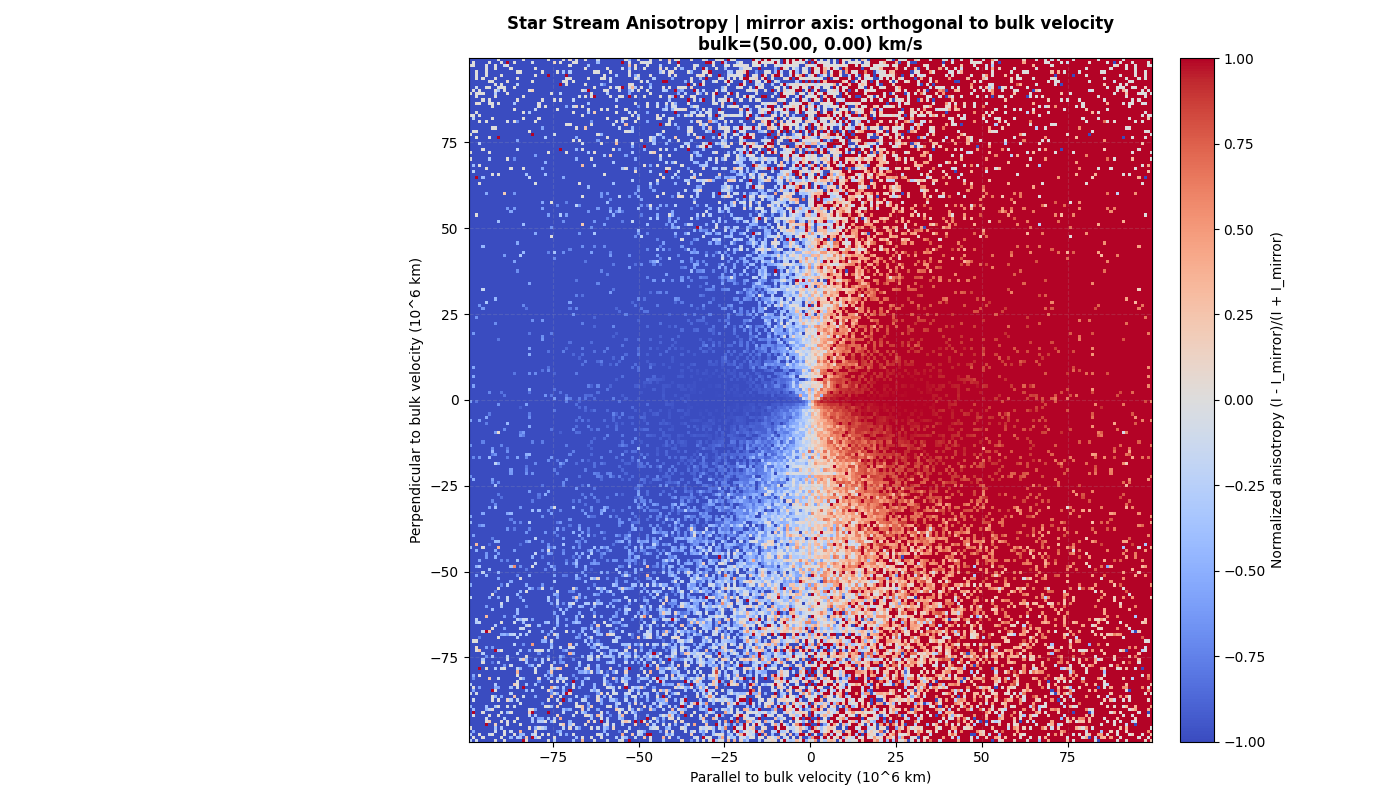

trajectory_phase_energy_planet.png


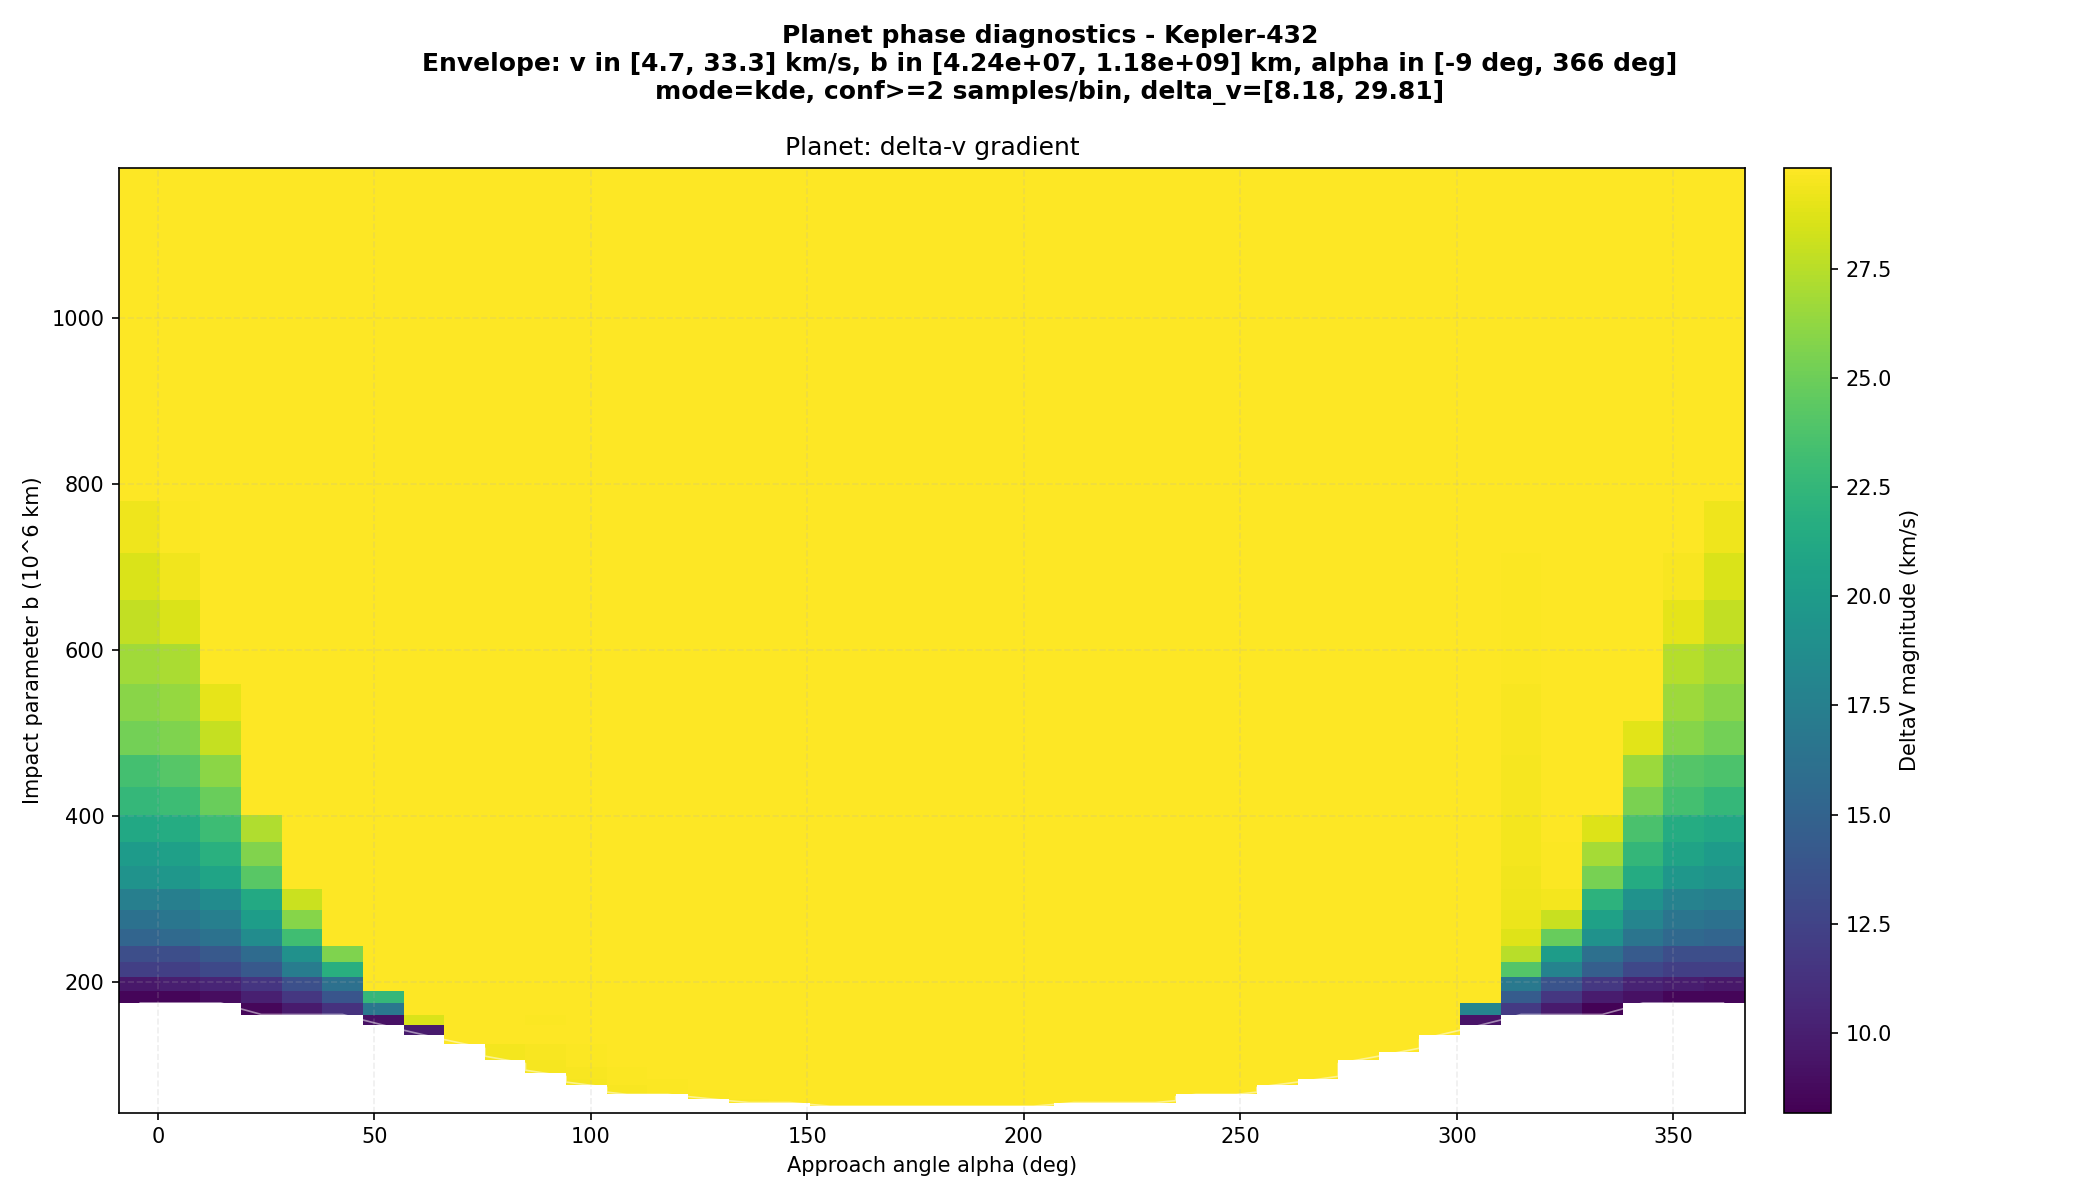

trajectory_phase_energy_star.png


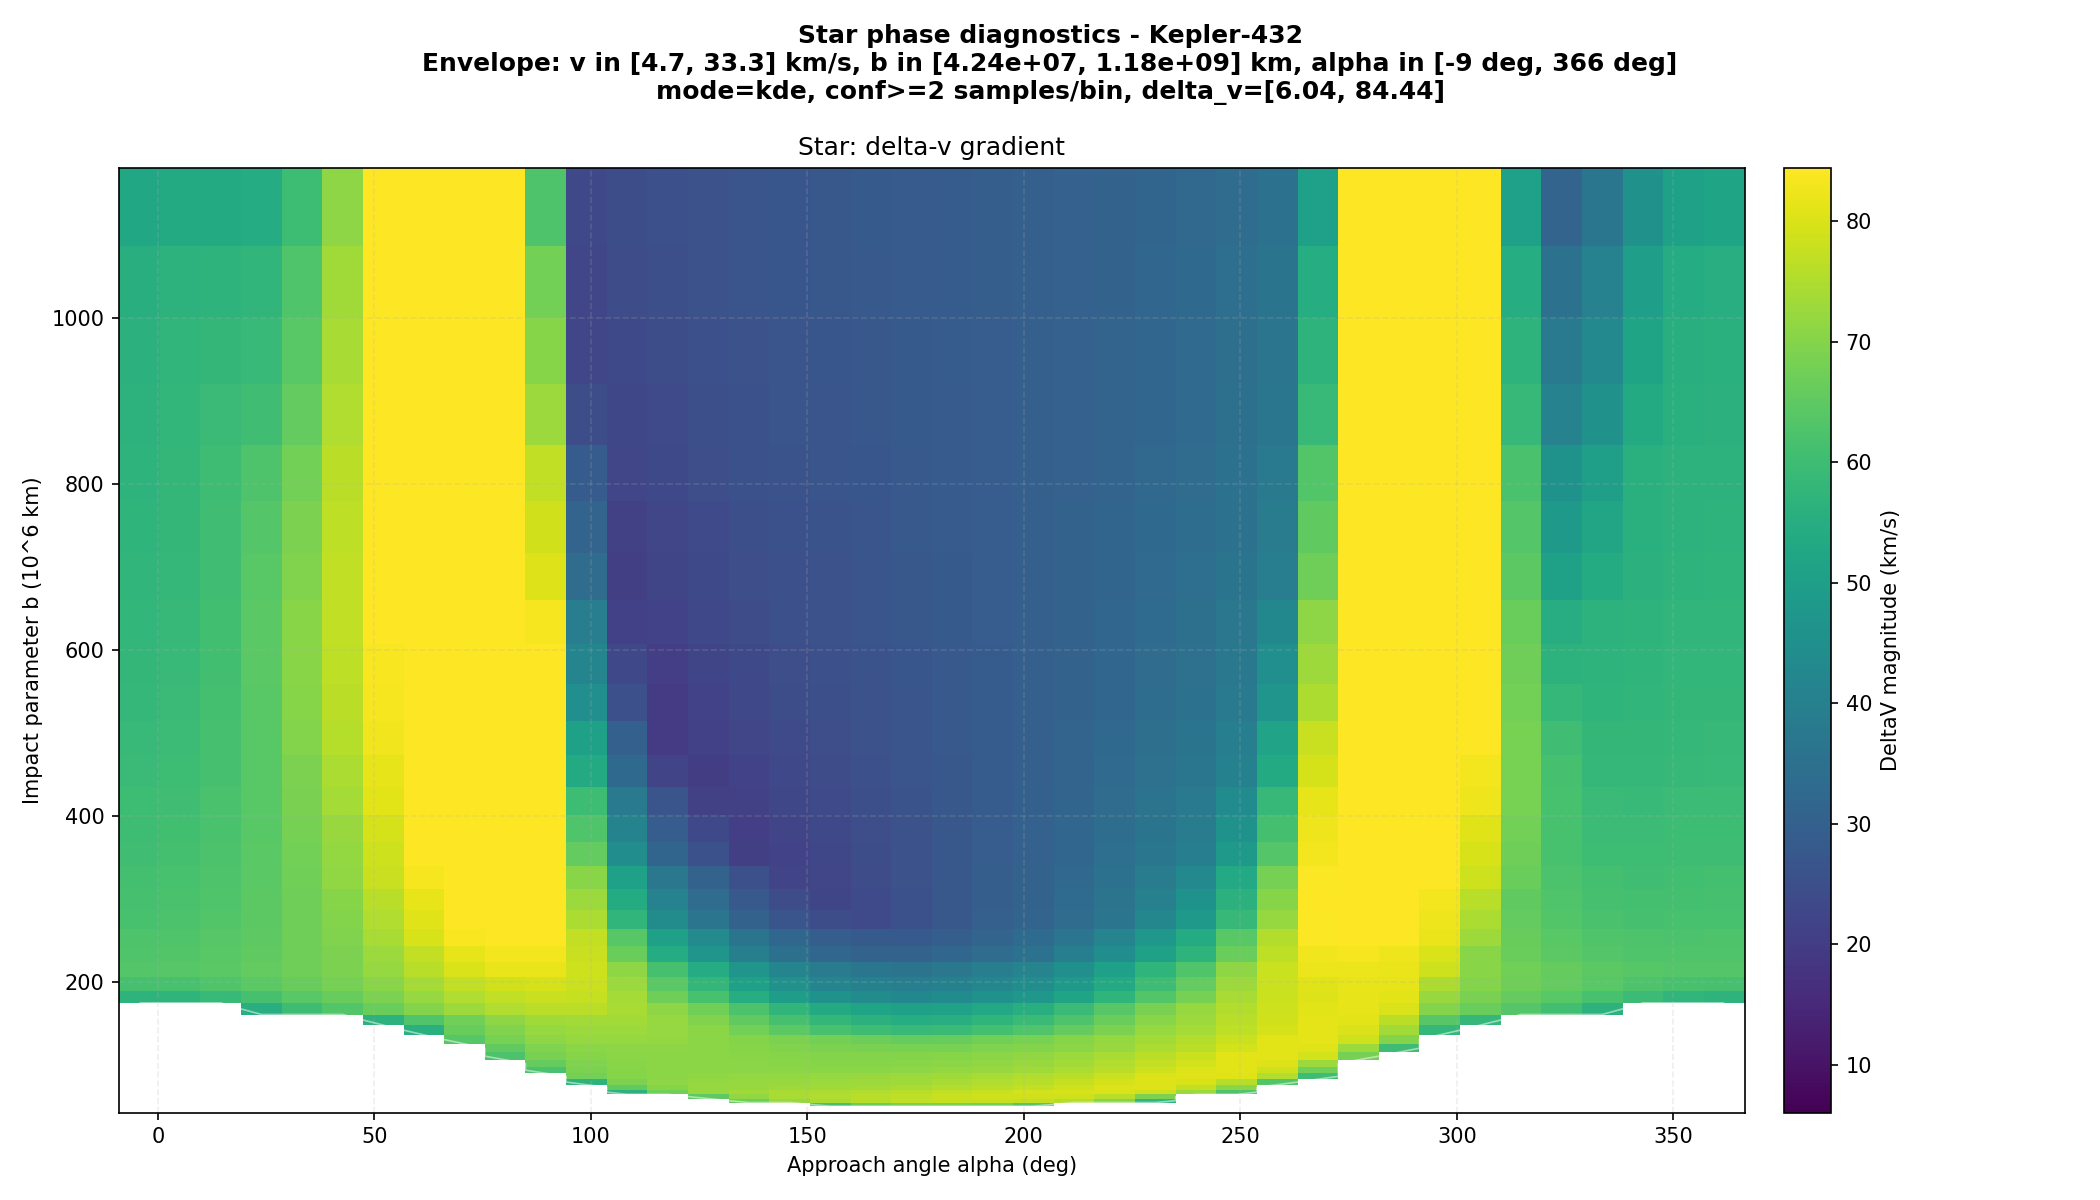

trajectory_phase_heading_planet.png


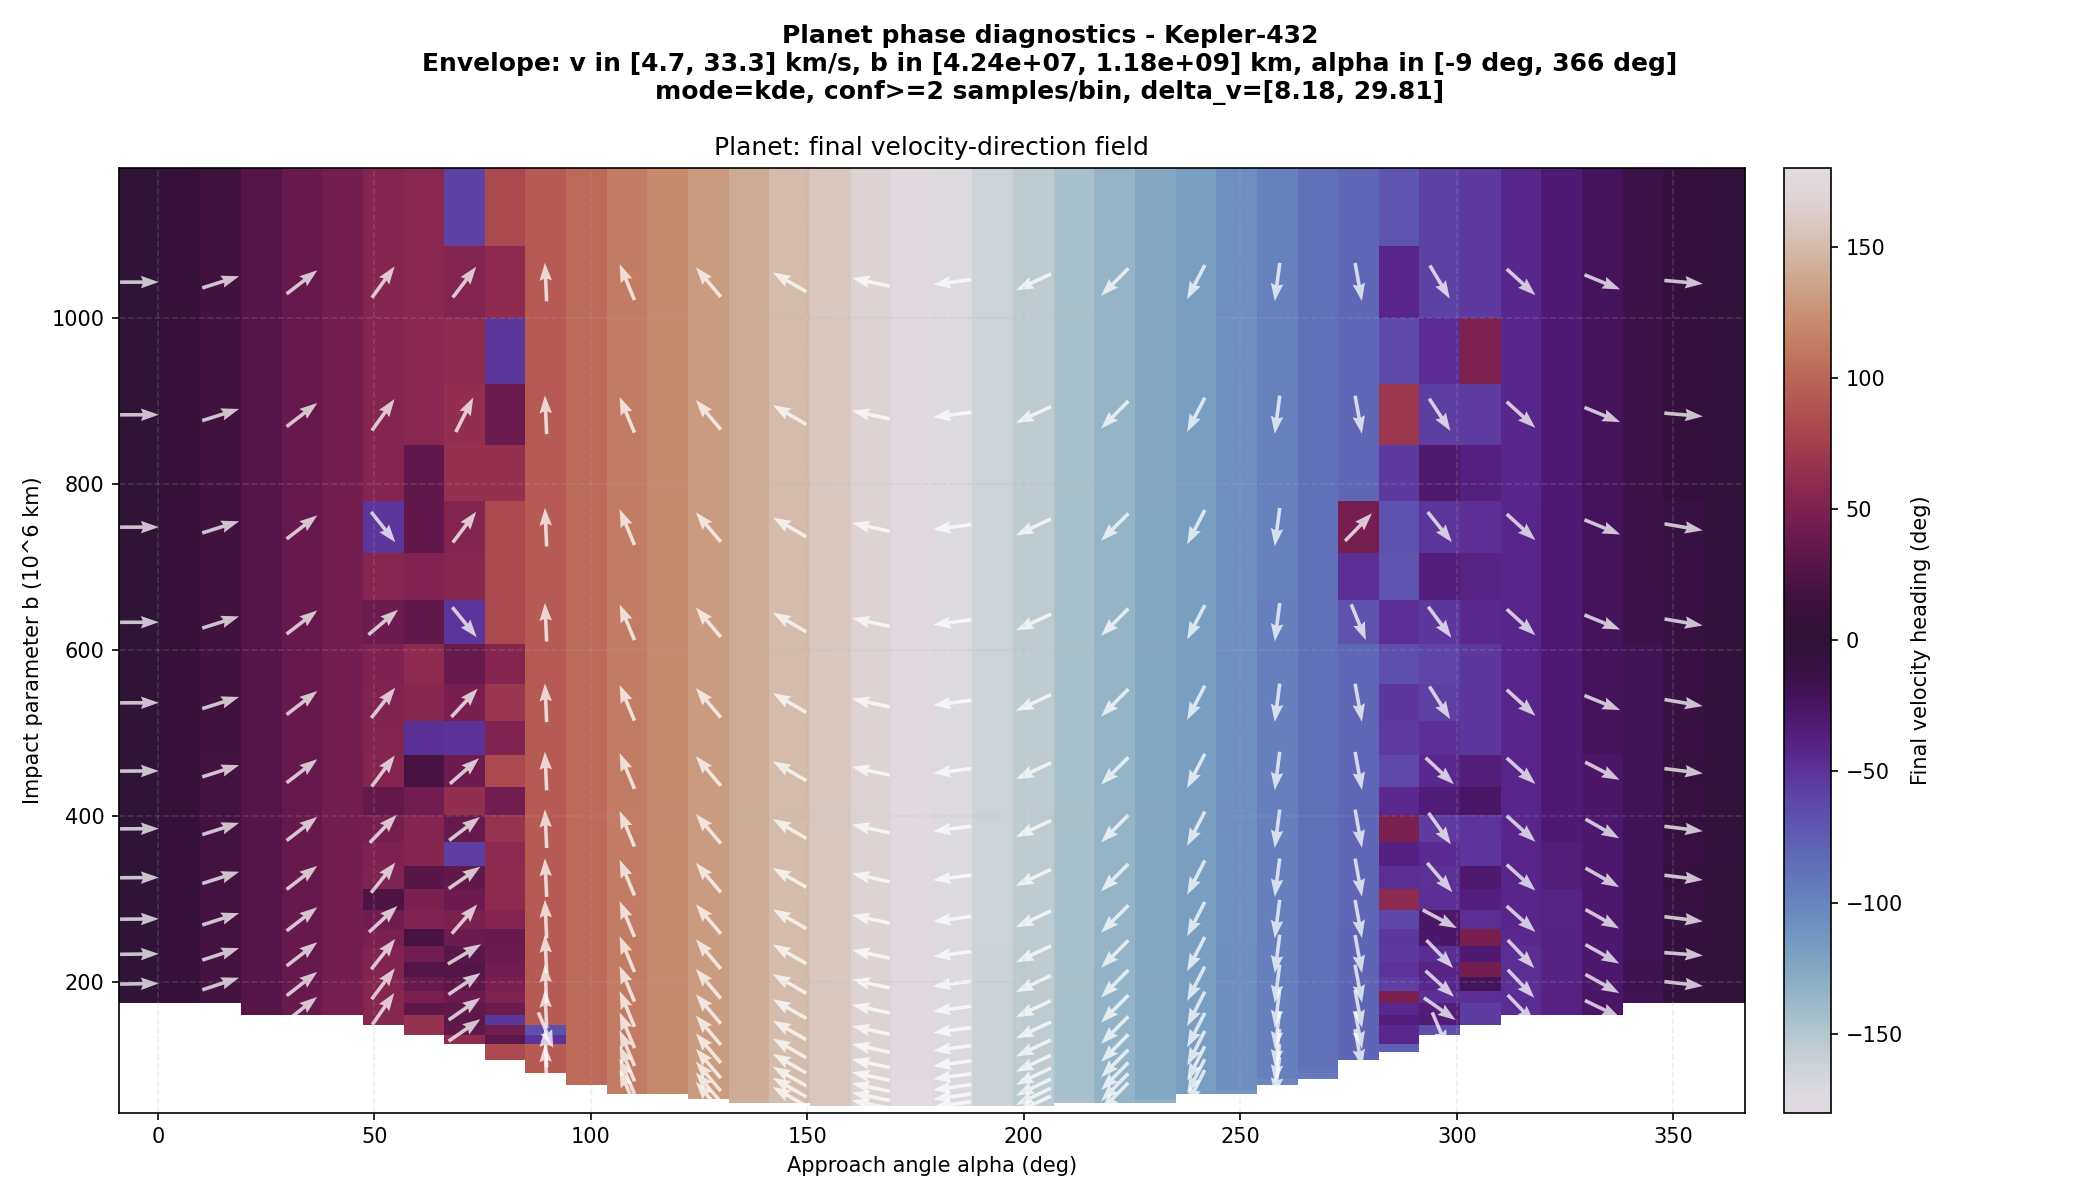

trajectory_phase_heading_star.png


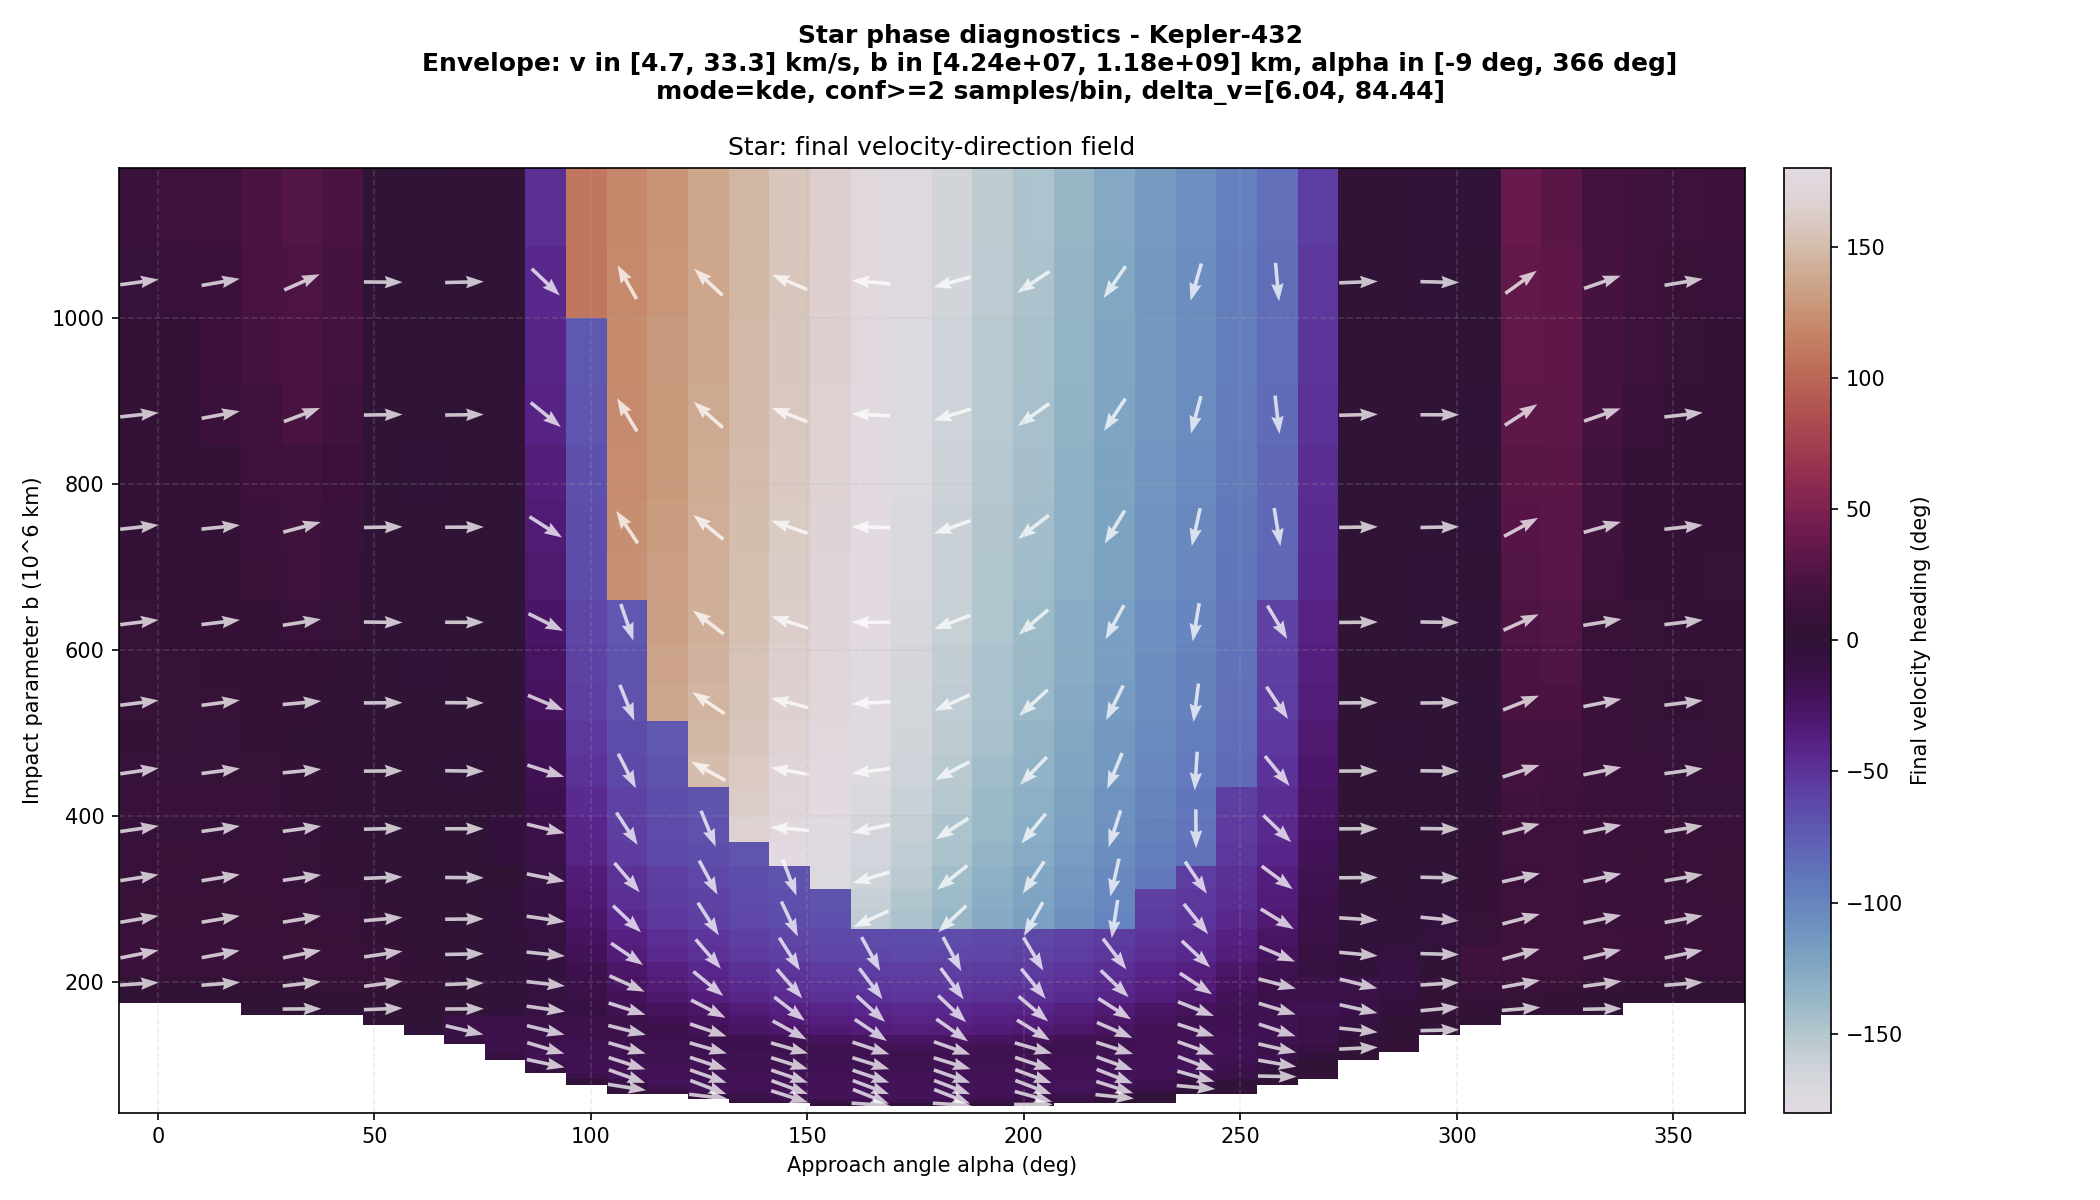

trajectory_tracks_planet.png


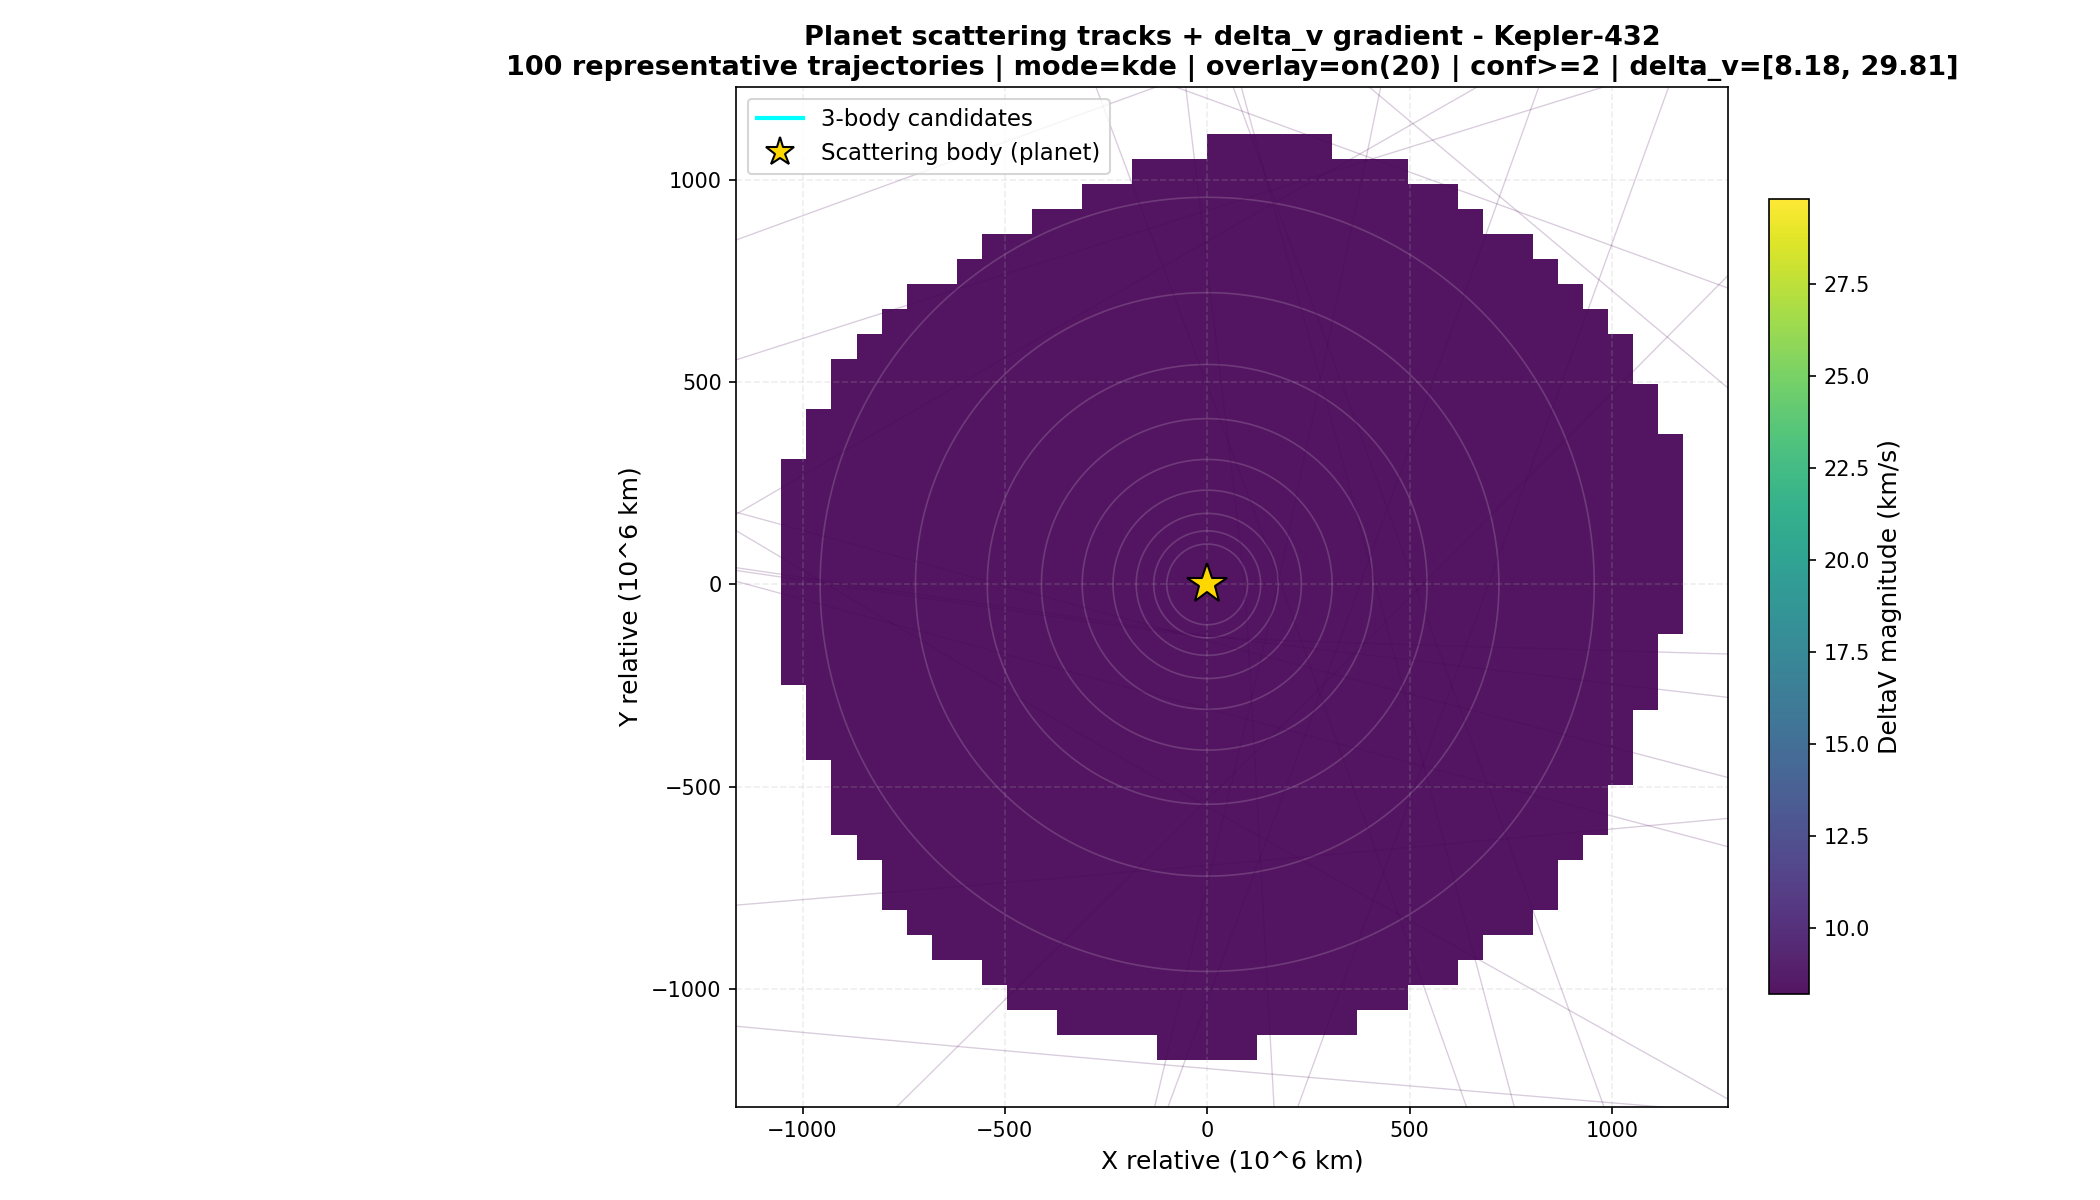

trajectory_tracks_star.png


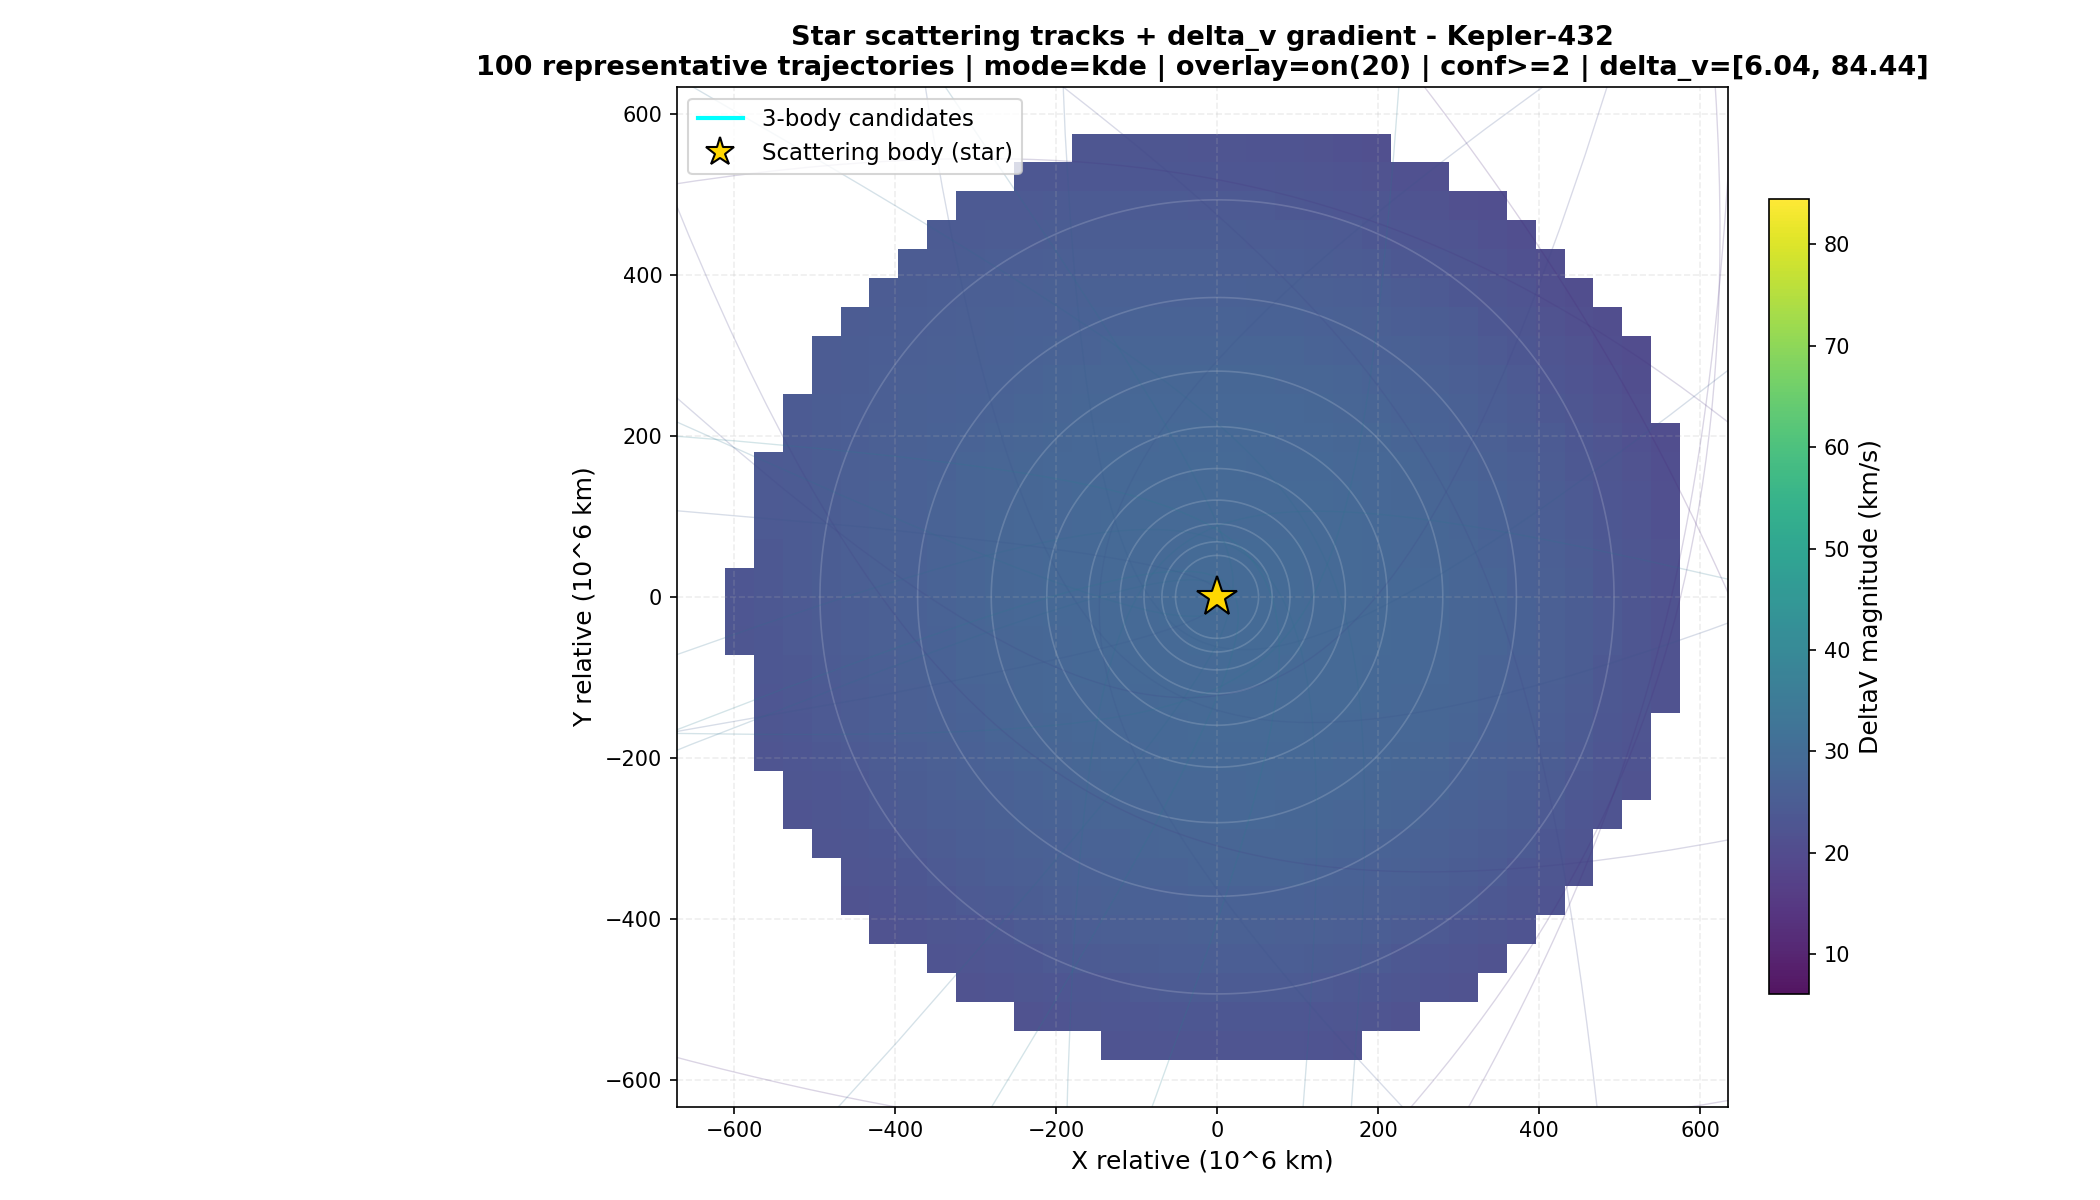

In [147]:
for p in generated_files:
    print(p.name)
    if p.suffix.lower() in {'.png', '.gif'} and p.exists():
        display(Image(filename=str(p)))


